##Import all necessary Libraries

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier




plt.style.use("default")
sns.set(font_scale=1.1)

Loading the data set

In [5]:
from google.colab import files

uploaded = files.upload()
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition 2.csv")

Saving WA_Fn-UseC_-HR-Employee-Attrition 2.csv to WA_Fn-UseC_-HR-Employee-Attrition 2.csv


In [6]:
# Dataset Shape
df.shape

(1470, 35)

In [7]:
#First 10 Records
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [8]:
#Statistical Summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [9]:
#Categorical Summary
df.describe(include = 'object')

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


In [10]:
#Missing value
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [11]:
df.isnull().sum().sum()

np.int64(0)

In [12]:
#Duplicate Record
df.duplicated().sum()

np.int64(0)

In [13]:
#Target Variable Distribution
target_feature = "Attrition"
df[target_feature].value_counts()

,count
Attrition,
No,1233
Yes,237


In [14]:
#Unique values per column
df.nunique().sort_values()

,0
EmployeeCount,1
Over18,1
StandardHours,1
Attrition,2
OverTime,2
PerformanceRating,2
Gender,2
BusinessTravel,3
Department,3
MaritalStatus,3


##Exploratory Data Analysis

Numerical Feature Analysis

In [15]:
numerical_col = df.select_dtypes(include=['int64','float64']).columns.tolist()
print(numerical_col)

['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [16]:
#Continuous Fearures
continuous_features = [
    'Age',
    'DailyRate',
    'DistanceFromHome',
    'HourlyRate',
    'MonthlyIncome',
    'MonthlyRate',
    'NumCompaniesWorked',
    'PercentSalaryHike',
    'TotalWorkingYears',
    'YearsAtCompany',
    'YearsInCurrentRole',
    'YearsSinceLastPromotion',
    'YearsWithCurrManager'
]

In [17]:
#Ordinal Features
ordinal_features = [
    'Education',
    'EnvironmentSatisfaction',
    'JobInvolvement',
    'JobLevel',
    'JobSatisfaction',
    'PerformanceRating',
    'RelationshipSatisfaction',
    'StockOptionLevel',
    'TrainingTimesLastYear',
    'WorkLifeBalance'
]

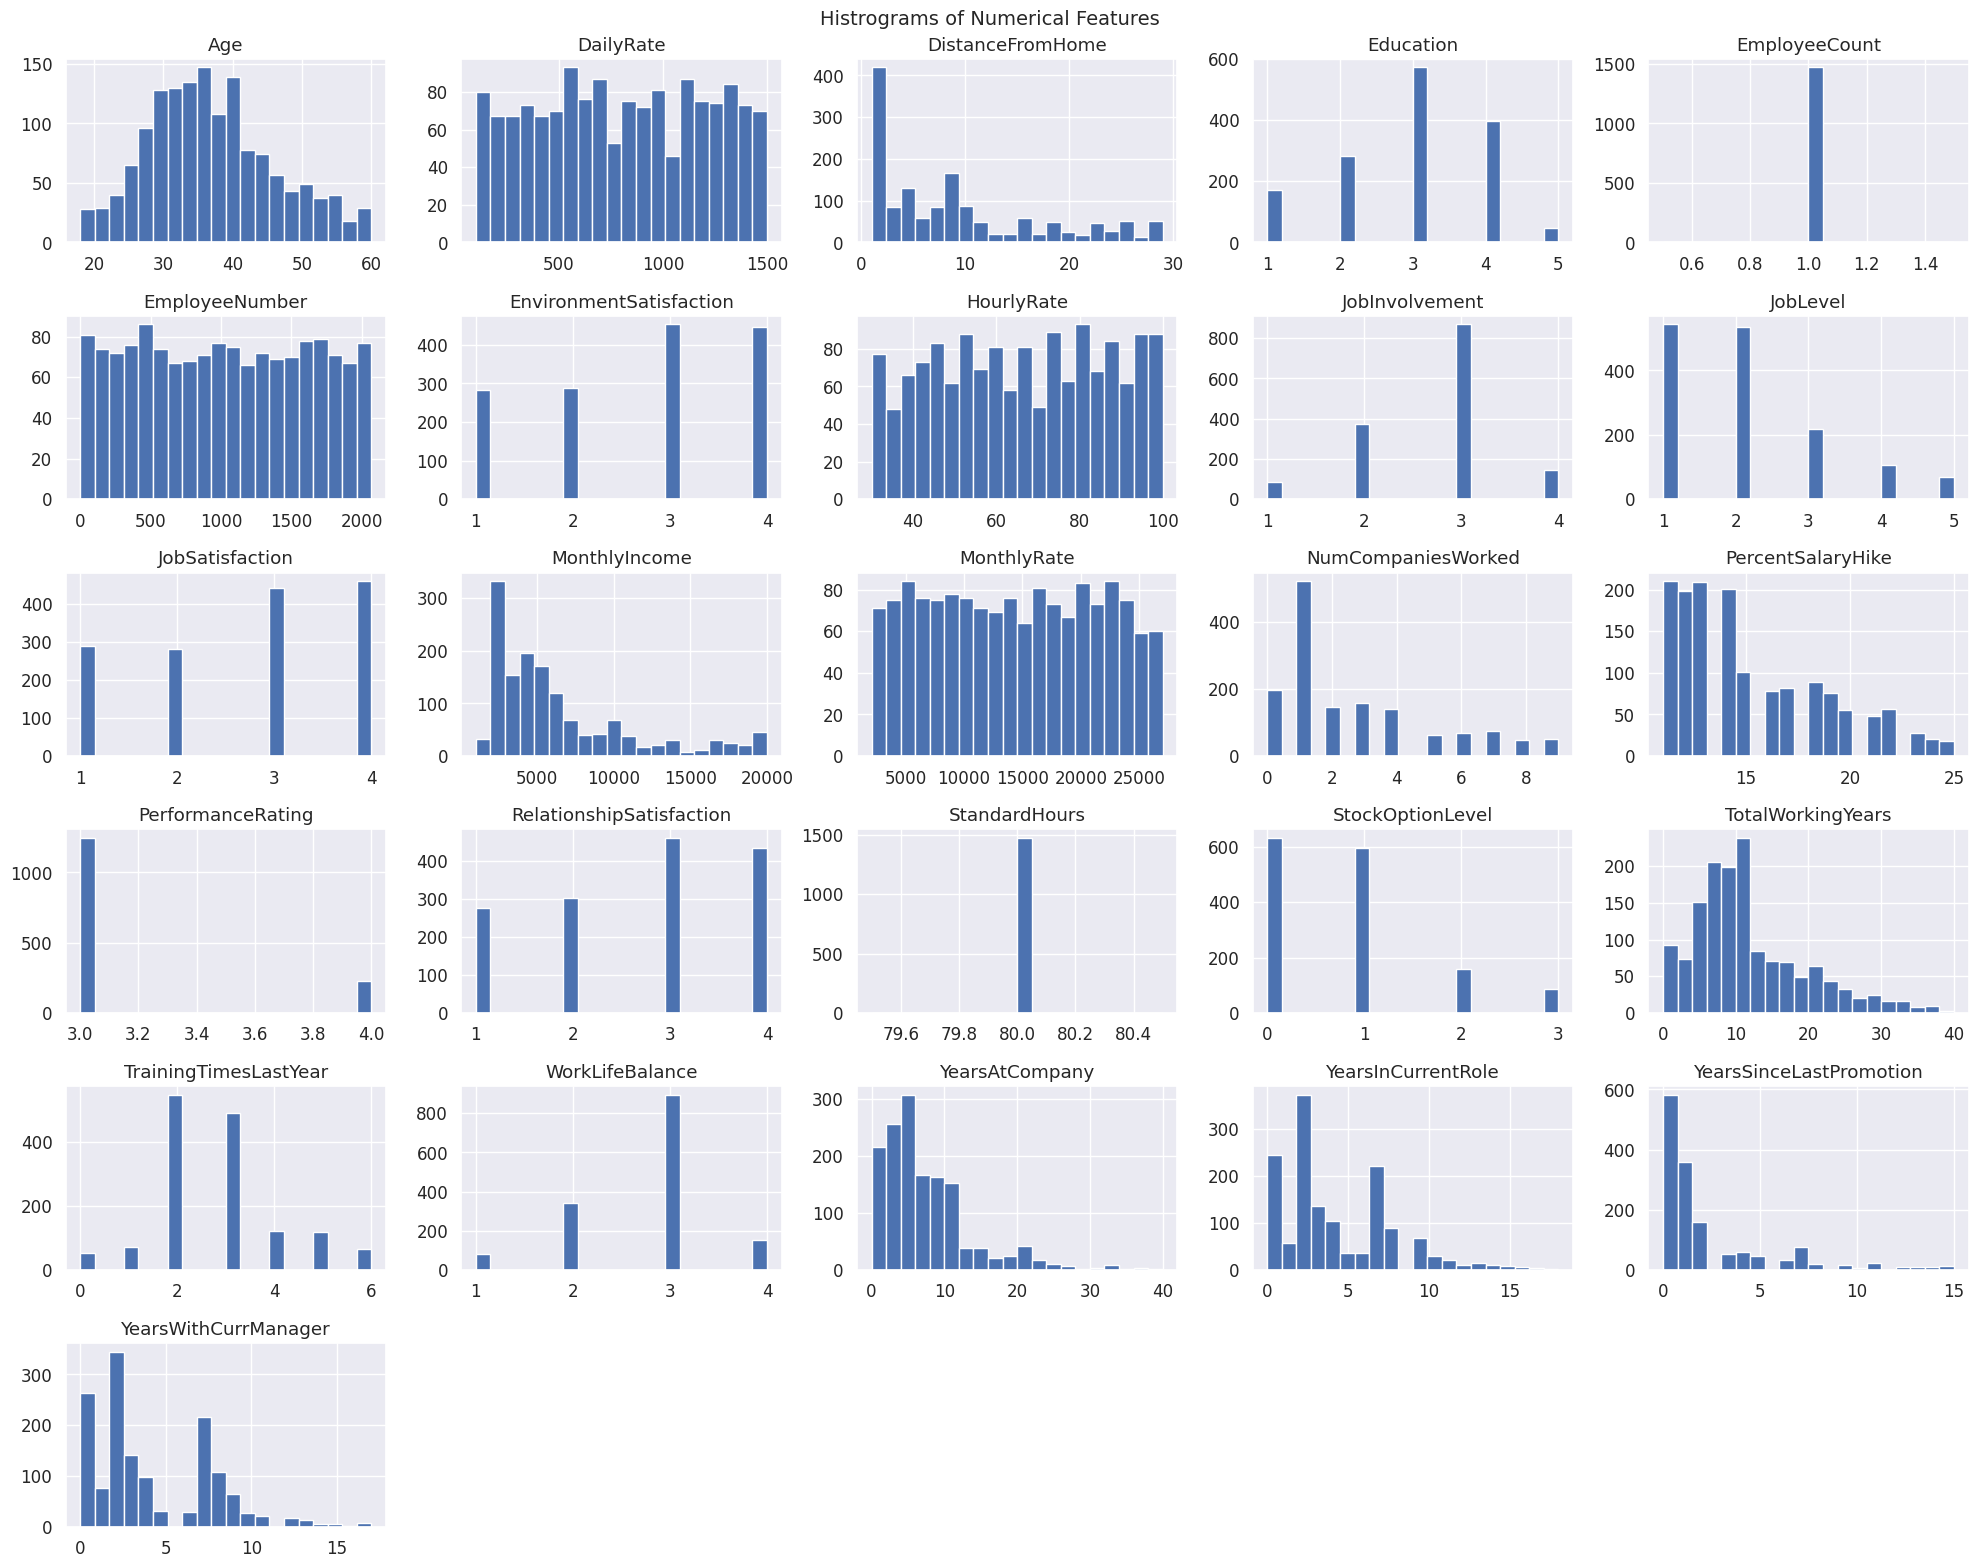

In [18]:
df[numerical_col].hist(bins=20, figsize=(20,16))
plt.suptitle("Histrograms of Numerical Features", fontsize = 14)
plt.tight_layout()
plt.show()

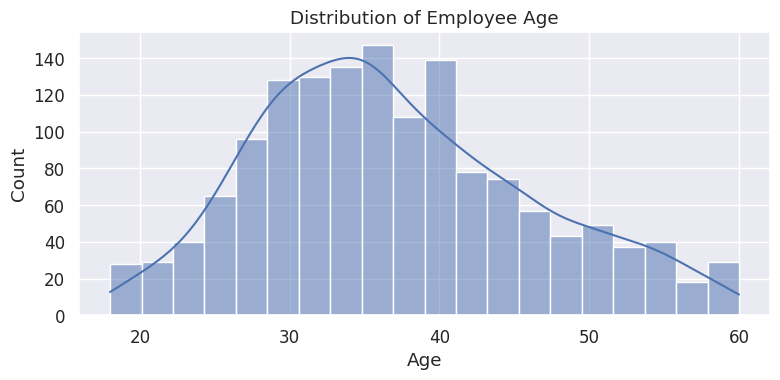

In [19]:
plt.figure(figsize=(8,4))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Distribution of Employee Age")
plt.tight_layout()
plt.show()

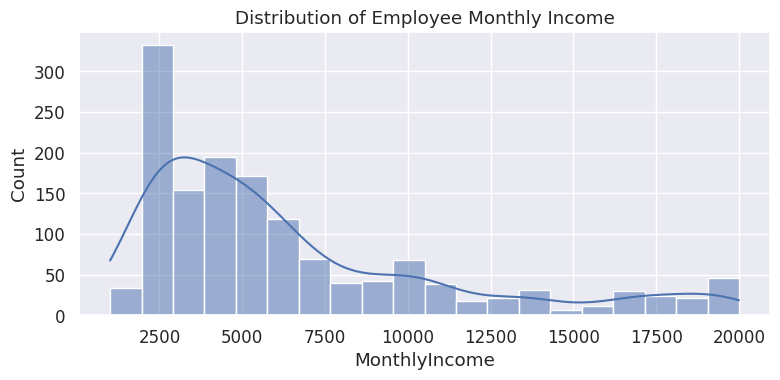

In [20]:
plt.figure(figsize=(8,4))
sns.histplot(df["MonthlyIncome"], bins=20, kde=True)
plt.title("Distribution of Employee Monthly Income")
plt.tight_layout()
plt.show()

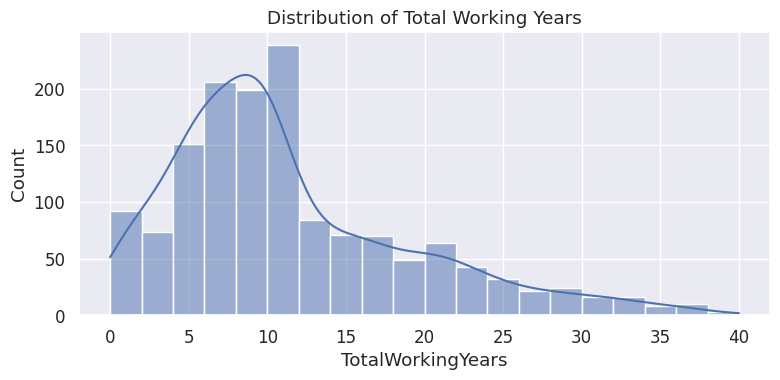

In [21]:
plt.figure(figsize=(8,4))
sns.histplot(df["TotalWorkingYears"], bins=20, kde=True)
plt.title("Distribution of Total Working Years")
plt.tight_layout()
plt.show()

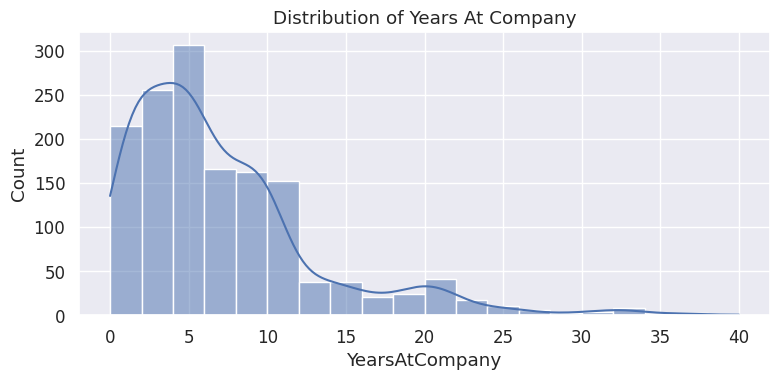

In [22]:
plt.figure(figsize=(8,4))
sns.histplot(df["YearsAtCompany"], bins=20, kde=True)
plt.title("Distribution of Years At Company")
plt.tight_layout()
plt.show()

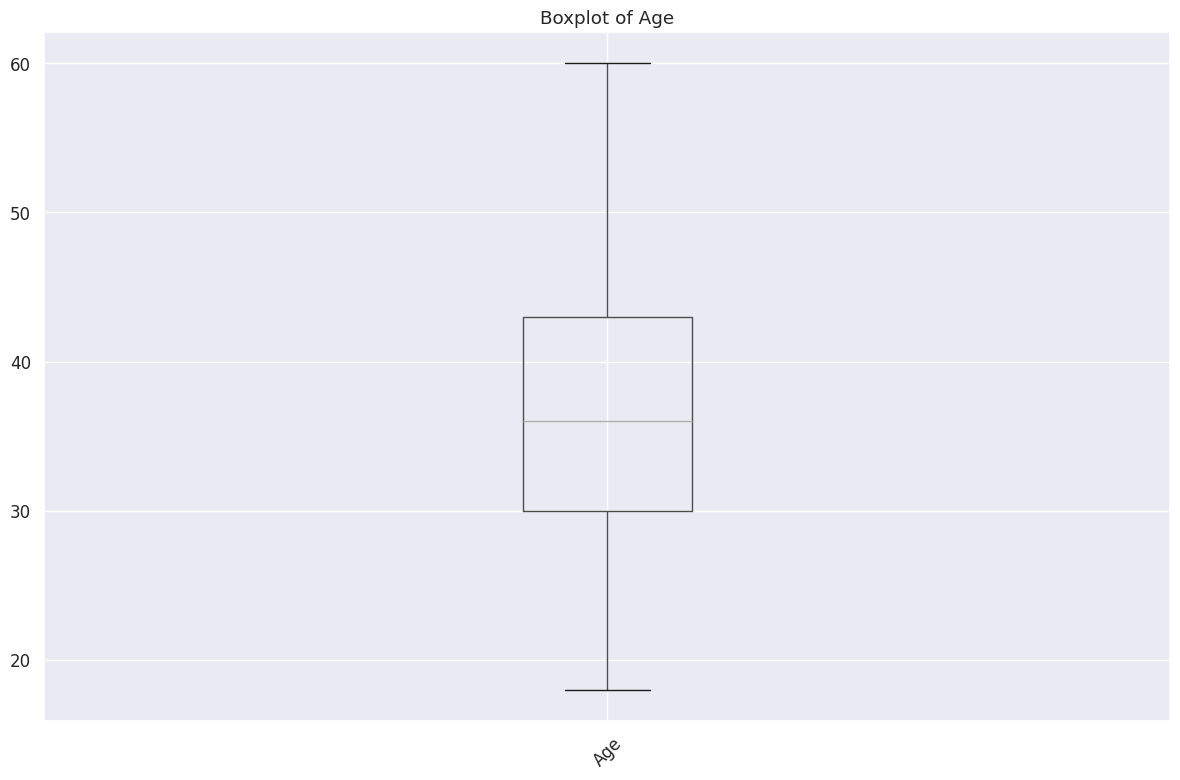

In [23]:
#Box plot for age
plt.figure(figsize=(12,8))
df.boxplot(column="Age")
plt.title("Boxplot of Age")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

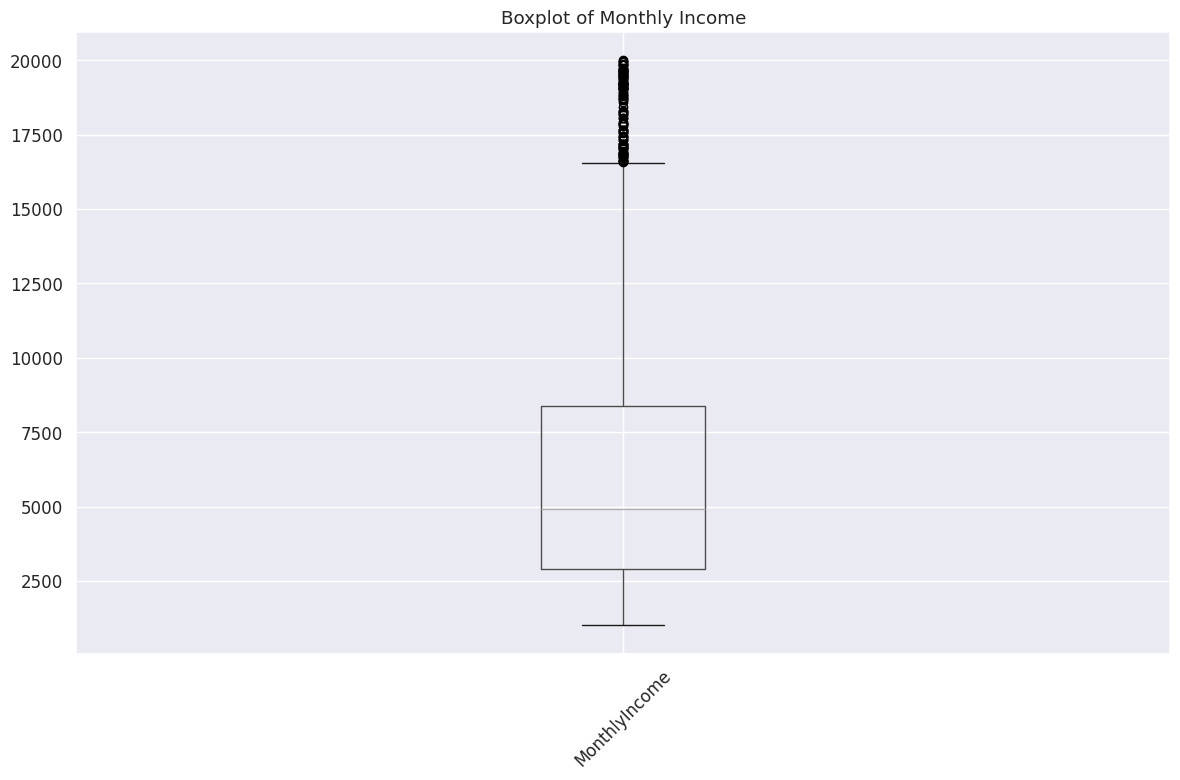

In [24]:
#Boxplot for Monthly Income
plt.figure(figsize=(12,8))
df.boxplot(column="MonthlyIncome")
plt.title("Boxplot of Monthly Income")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

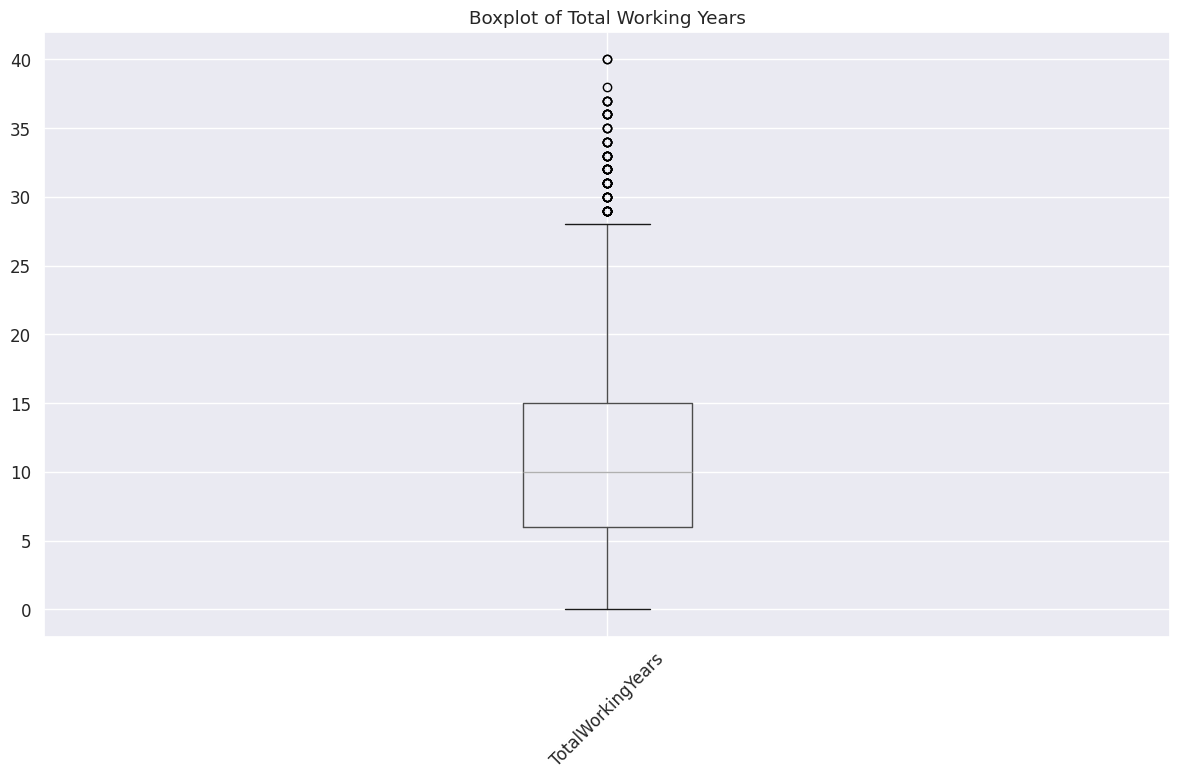

In [25]:
#Box plot for Total WOrking Hours
plt.figure(figsize=(12,8))
df.boxplot(column="TotalWorkingYears")
plt.title("Boxplot of Total Working Years")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

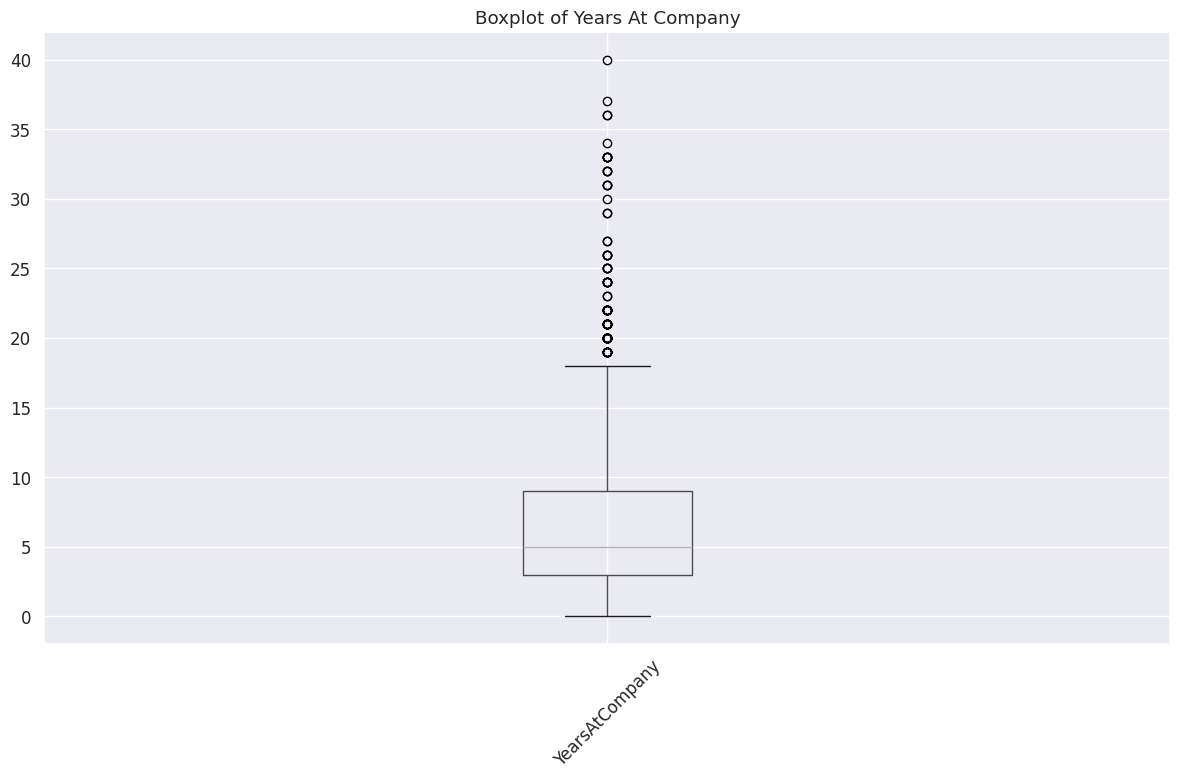

In [26]:
#Boxplot for Years at Company
plt.figure(figsize=(12,8))
df.boxplot(column="YearsAtCompany")
plt.title("Boxplot of Years At Company")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Ordinal Feature Exploration

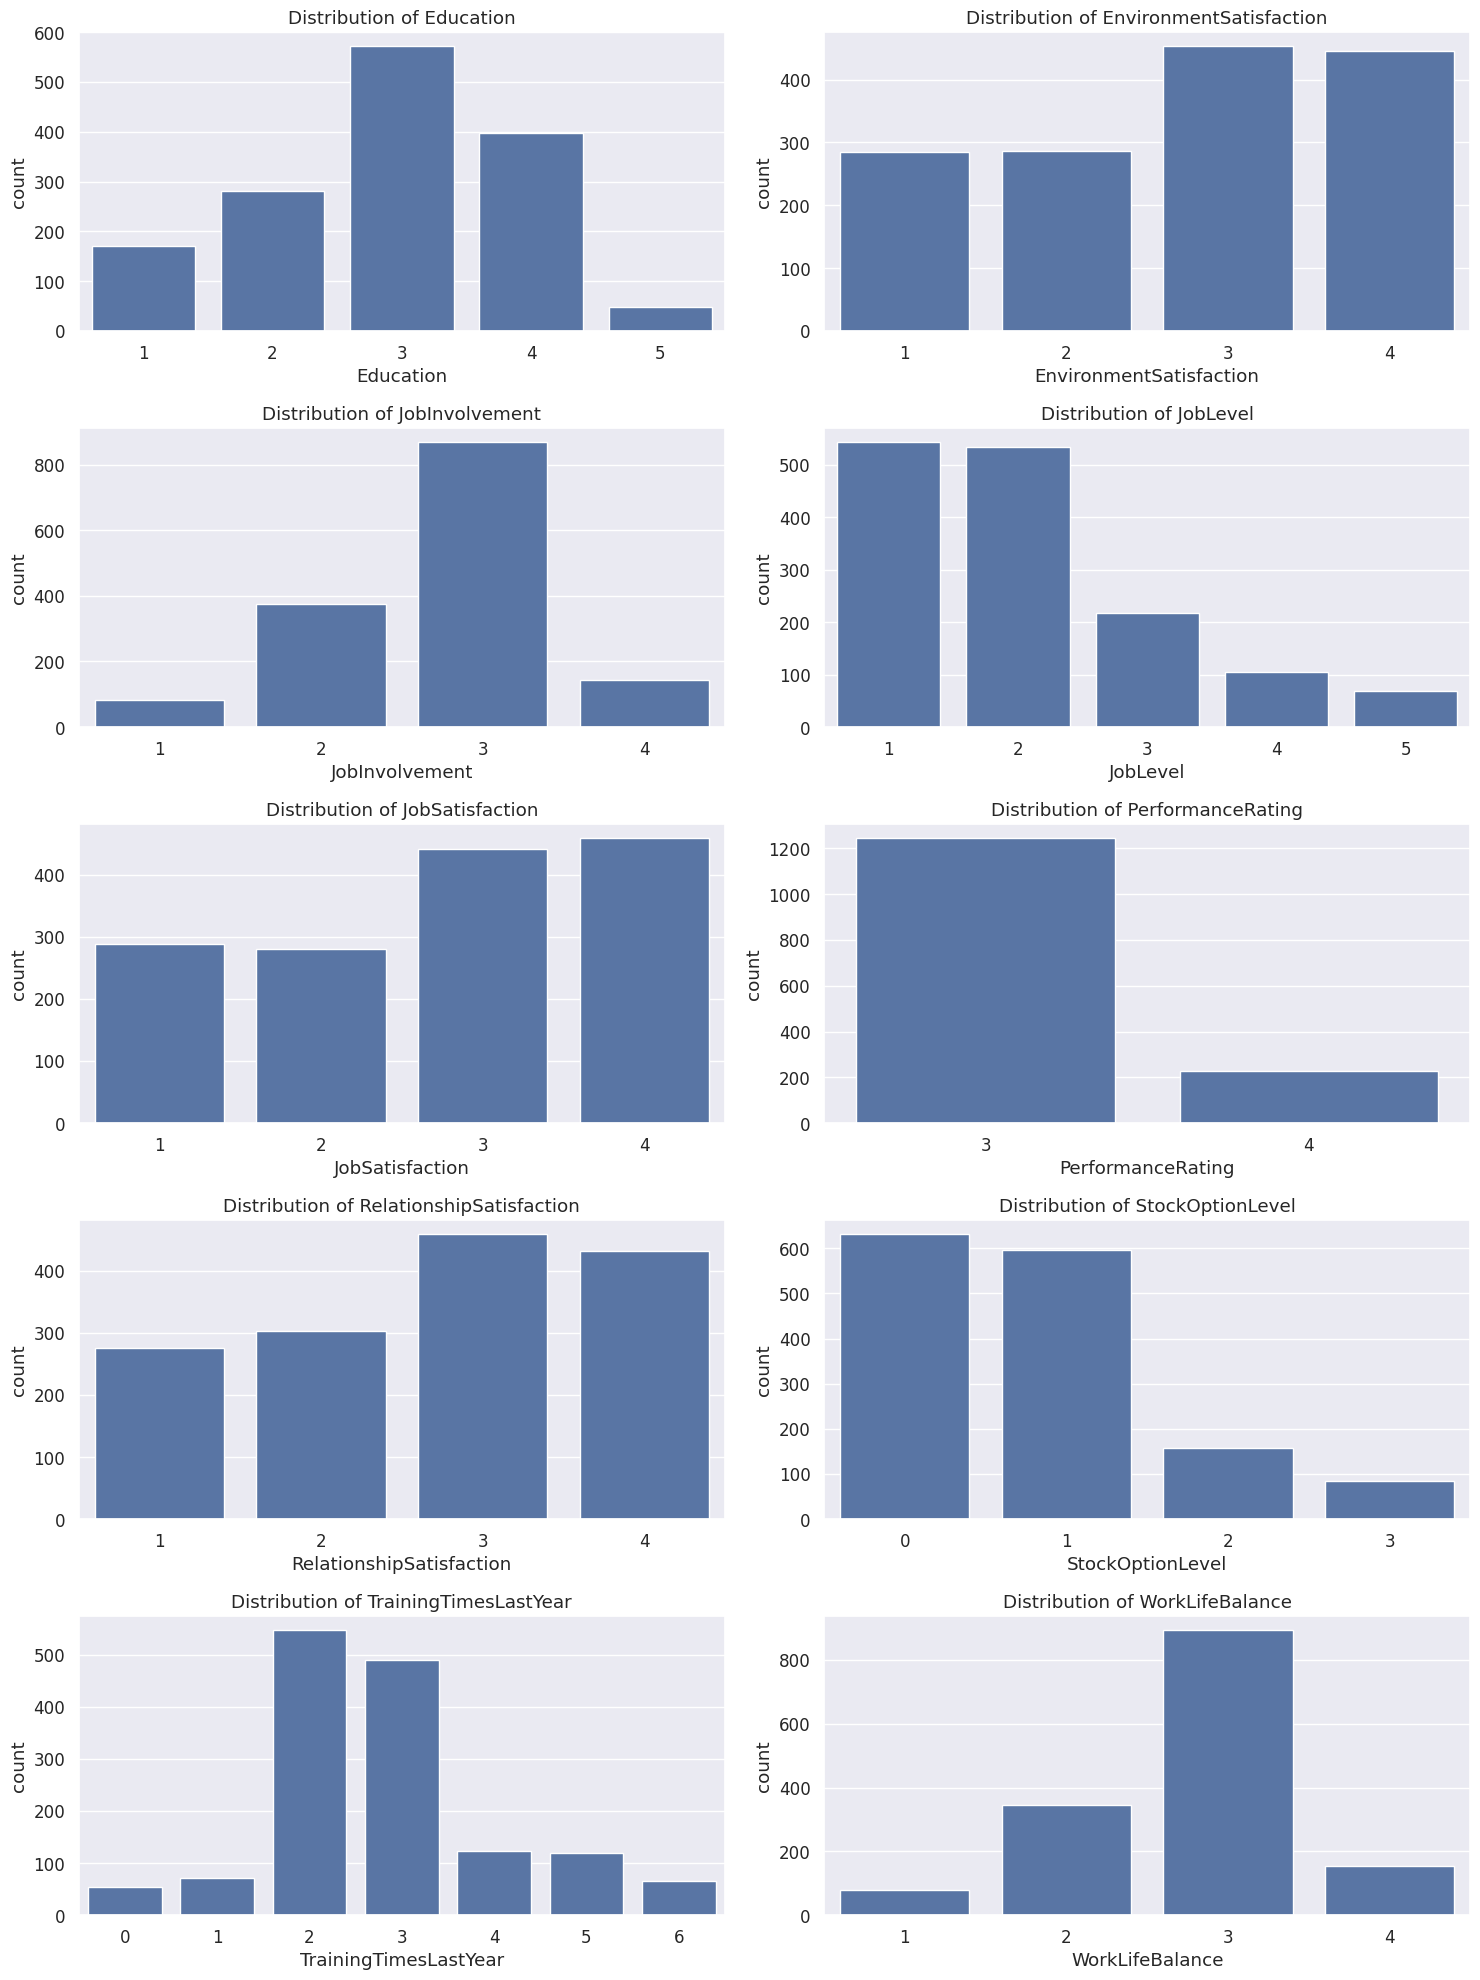

In [27]:
#Count plot for ordinal features
fig, axes = plt.subplots(5, 2, figsize=(15, 20))

for col, ax in zip(ordinal_features, axes.flatten()):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

Categorical Feature Exploration

In [28]:
categorical_features = [
    'BusinessTravel',
    'Department',
    'EducationField',
    'Gender',
    'JobRole',
    'MaritalStatus',
    'OverTime'
]

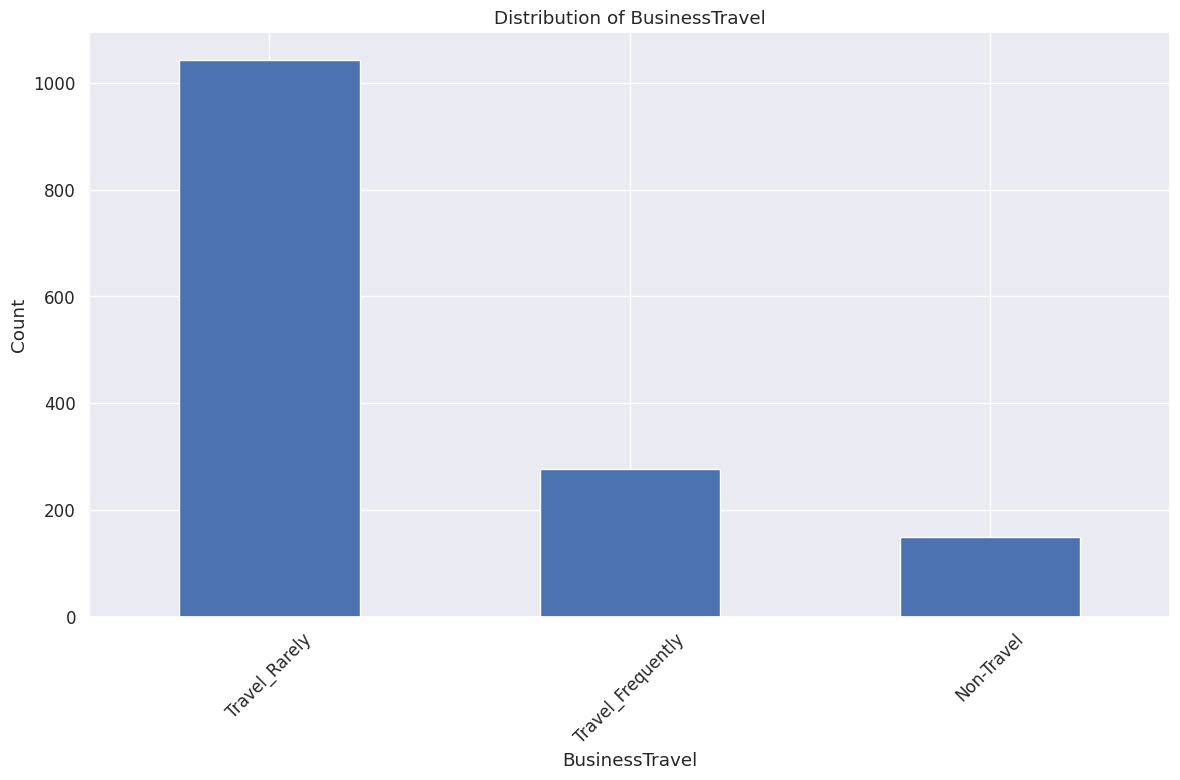

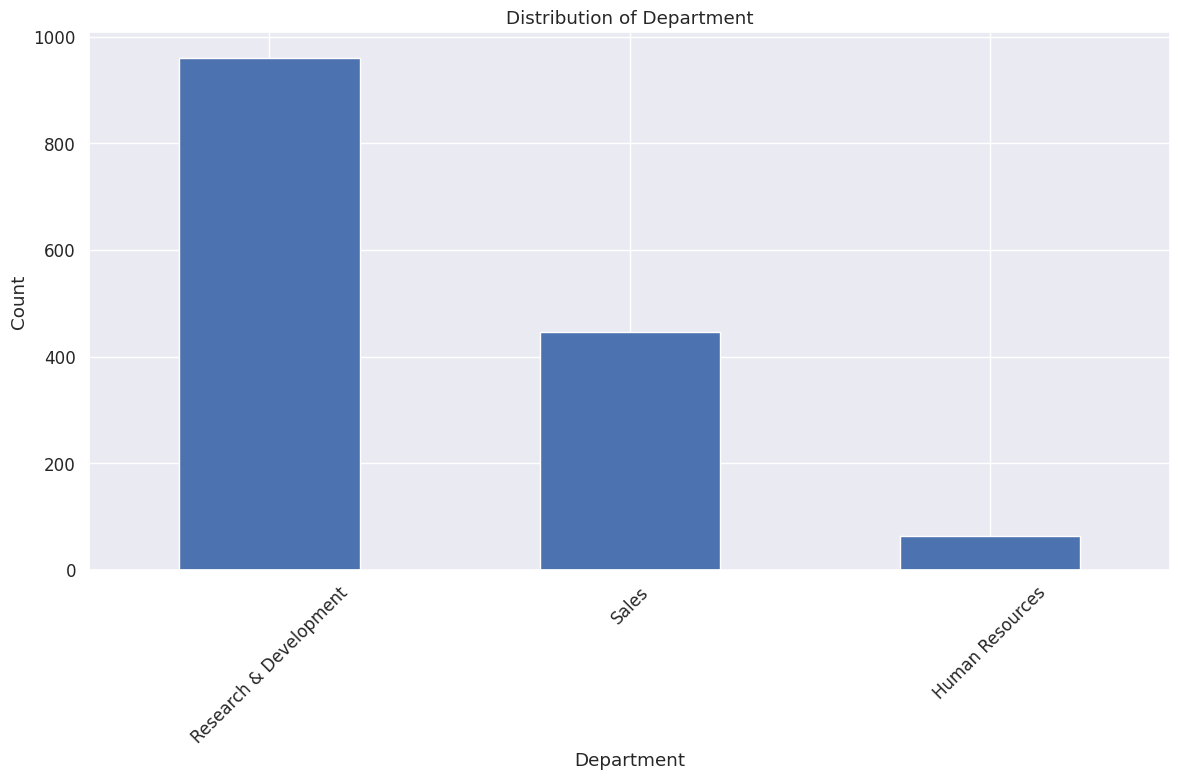

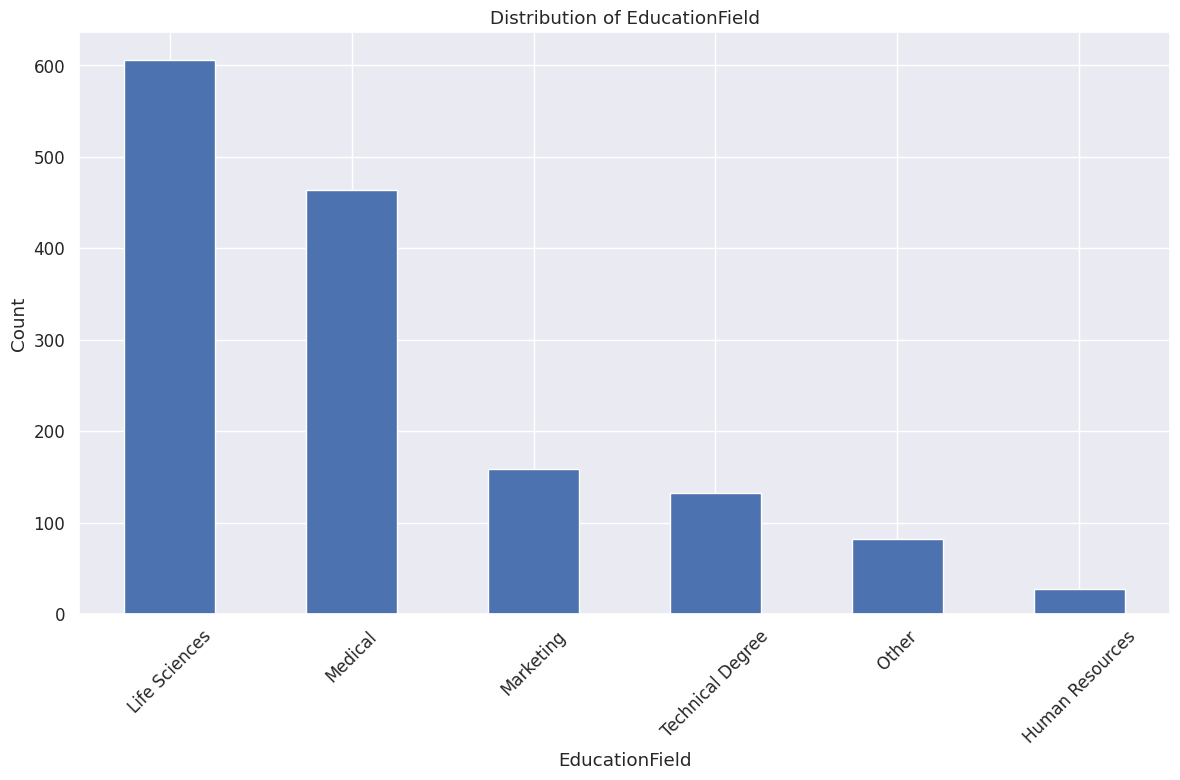

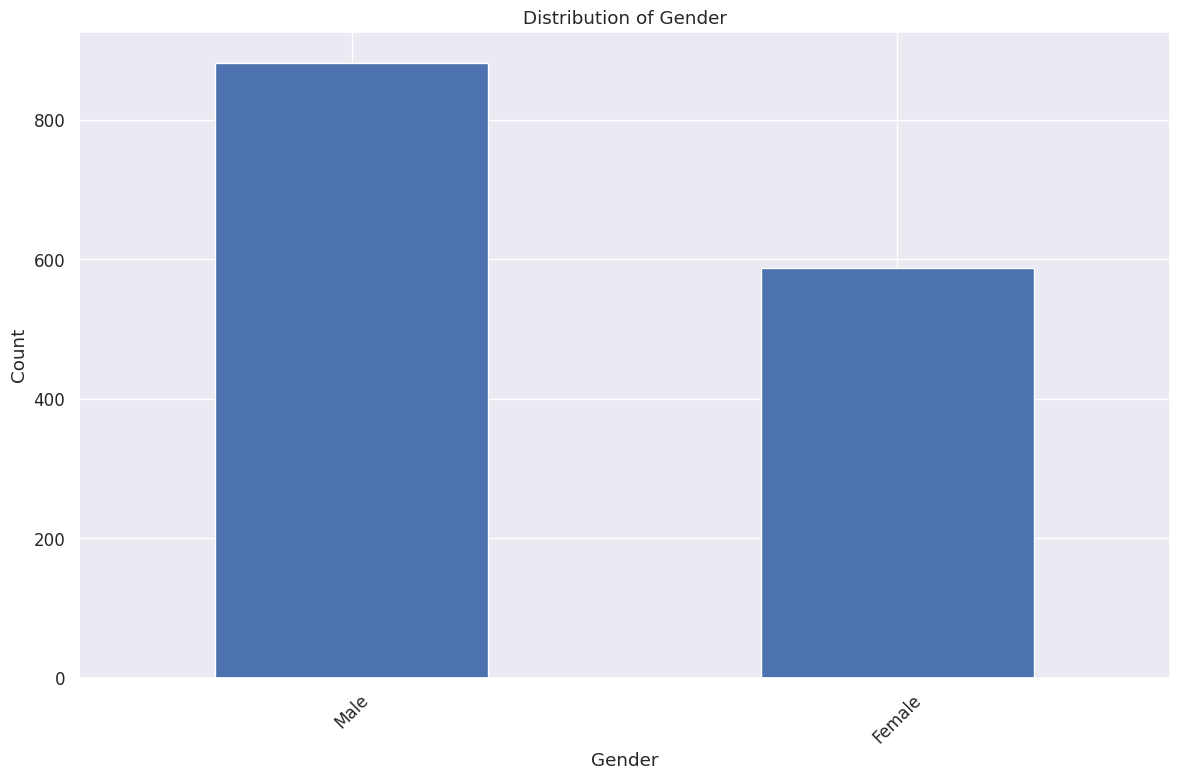

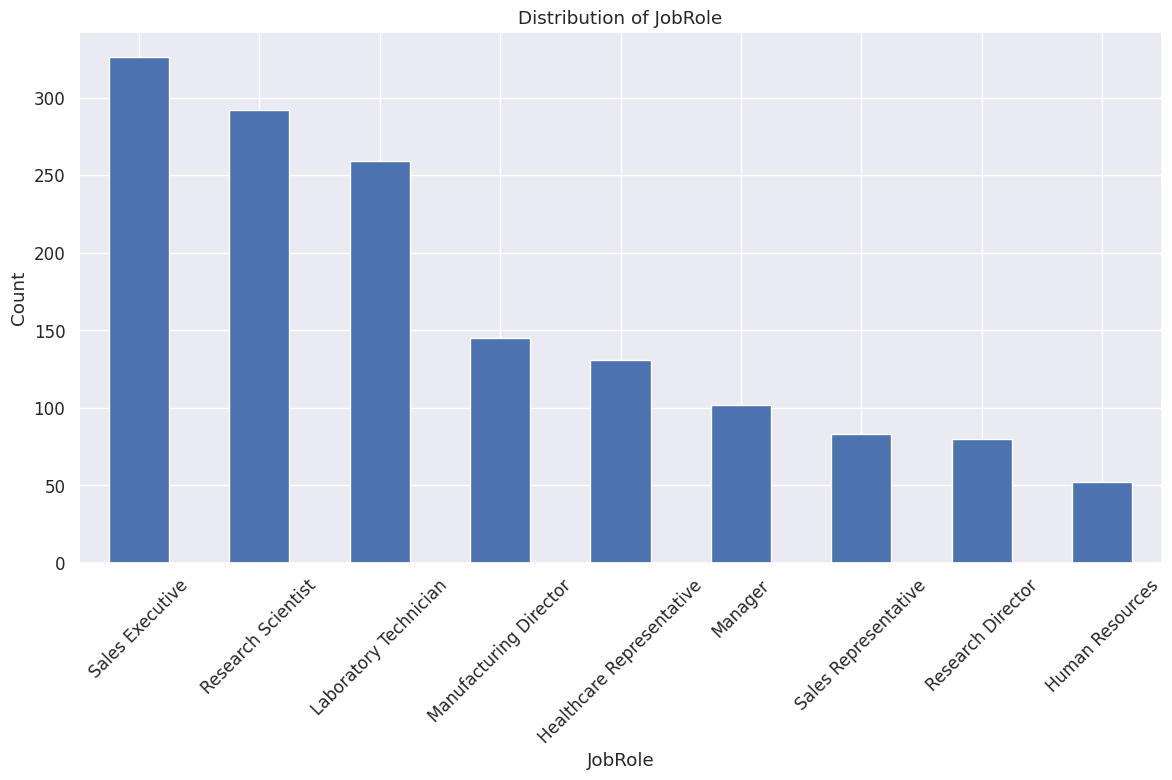

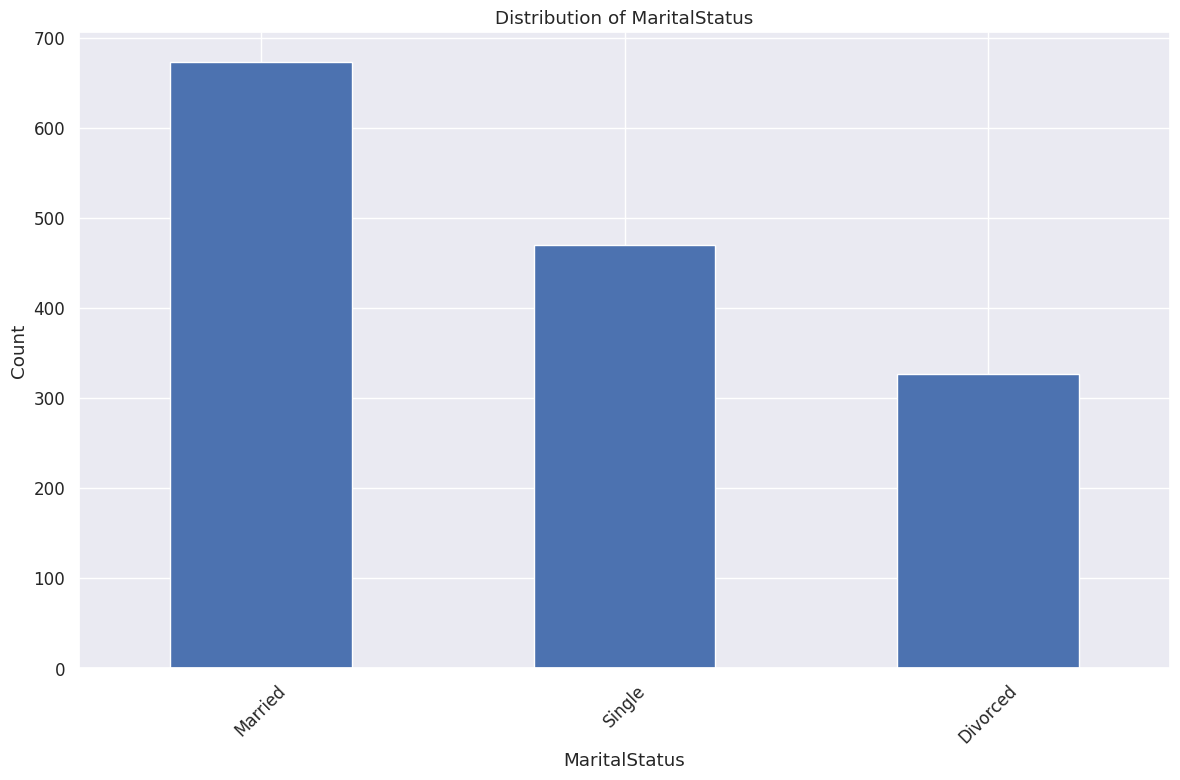

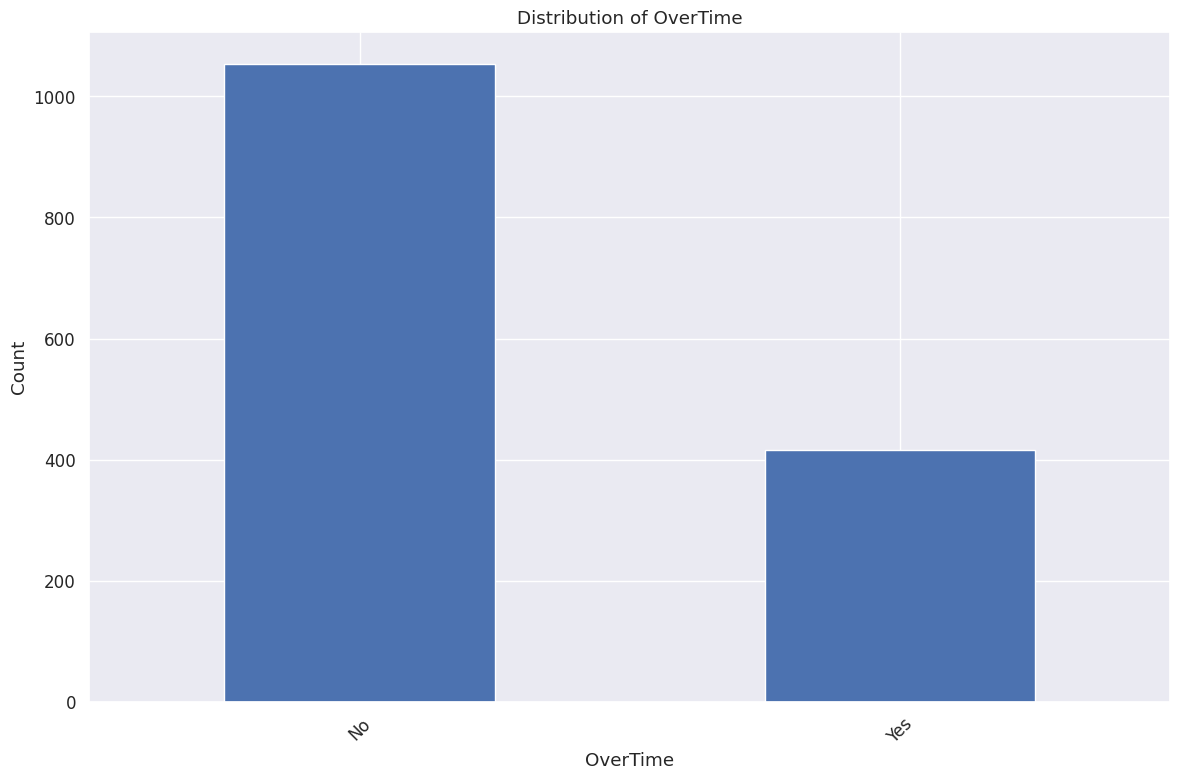

In [29]:
for c in categorical_features:
    plt.figure(figsize=(12,8))

    df[c].value_counts().plot(
        kind="bar"
    )

    plt.title(f"Distribution of {c}")
    plt.xlabel(c)
    plt.ylabel("Count")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

**Feature vs Attrition Analysis**

*Ordinal Features vs Attrition*


Attrition Percentage within Education


Attrition,No,Yes
Education,,
1,81.76,18.24
2,84.40,15.60
3,82.69,17.31
4,85.43,14.57
5,89.58,10.42


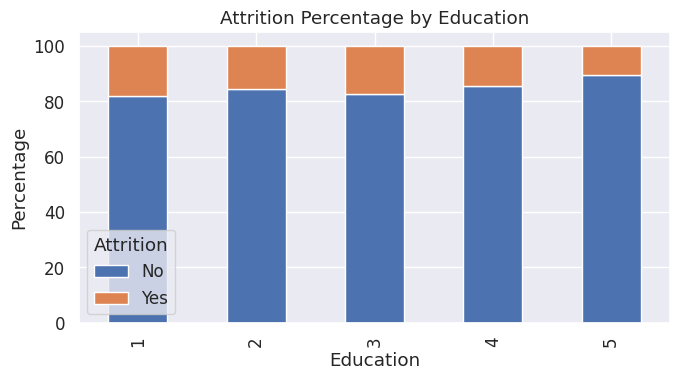


Attrition Percentage within EnvironmentSatisfaction


Attrition,No,Yes
EnvironmentSatisfaction,,
1,74.65,25.35
2,85.02,14.98
3,86.31,13.69
4,86.55,13.45


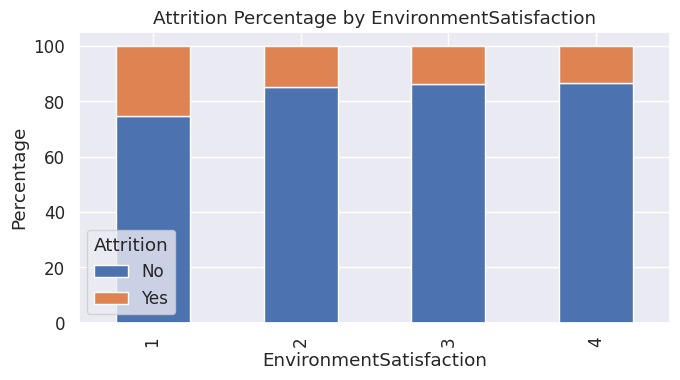


Attrition Percentage within JobInvolvement


Attrition,No,Yes
JobInvolvement,,
1,66.27,33.73
2,81.07,18.93
3,85.60,14.40
4,90.97,9.03


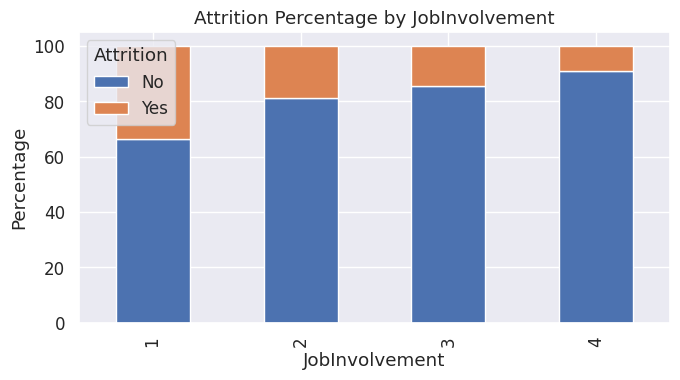


Attrition Percentage within JobLevel


Attrition,No,Yes
JobLevel,,
1,73.66,26.34
2,90.26,9.74
3,85.32,14.68
4,95.28,4.72
5,92.75,7.25


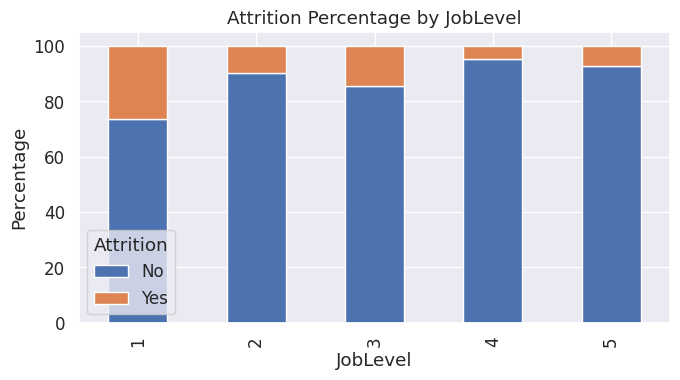


Attrition Percentage within JobSatisfaction


Attrition,No,Yes
JobSatisfaction,,
1,77.16,22.84
2,83.57,16.43
3,83.48,16.52
4,88.67,11.33


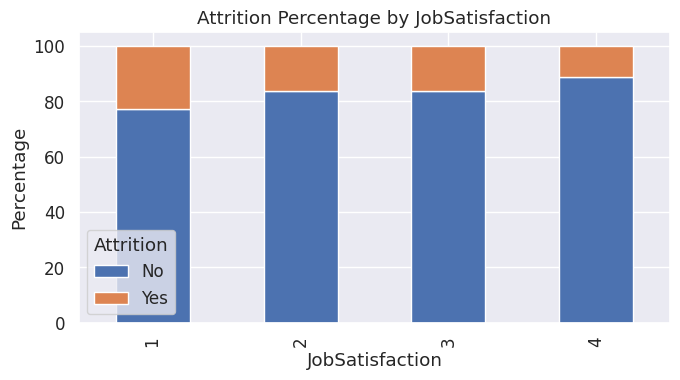


Attrition Percentage within PerformanceRating


Attrition,No,Yes
PerformanceRating,,
3,83.92,16.08
4,83.63,16.37


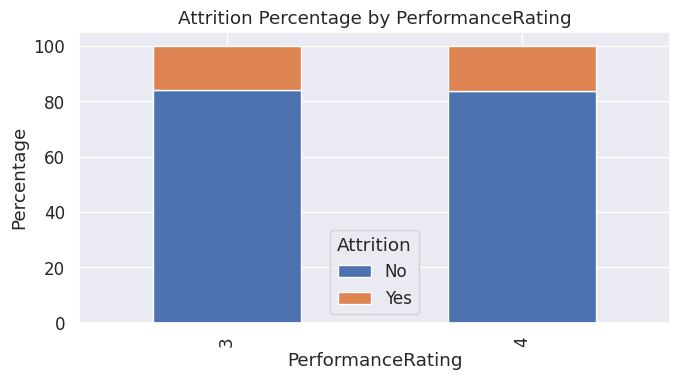


Attrition Percentage within RelationshipSatisfaction


Attrition,No,Yes
RelationshipSatisfaction,,
1,79.35,20.65
2,85.15,14.85
3,84.53,15.47
4,85.19,14.81


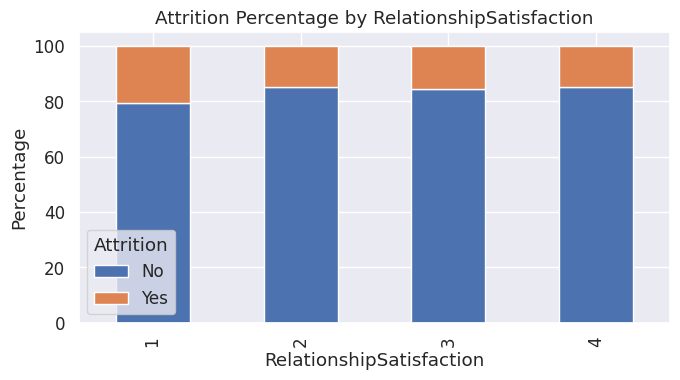


Attrition Percentage within StockOptionLevel


Attrition,No,Yes
StockOptionLevel,,
0,75.59,24.41
1,90.60,9.40
2,92.41,7.59
3,82.35,17.65


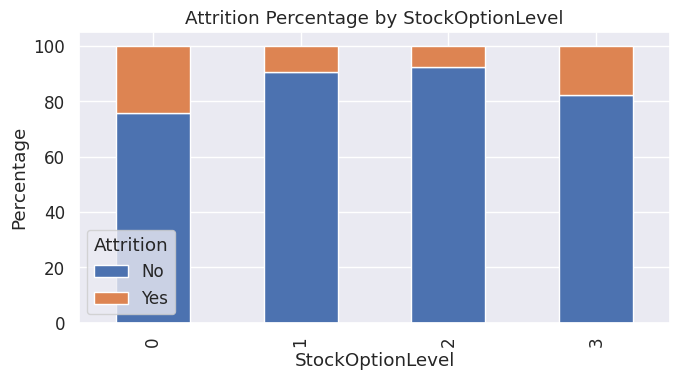


Attrition Percentage within TrainingTimesLastYear


Attrition,No,Yes
TrainingTimesLastYear,,
0,72.22,27.78
1,87.32,12.68
2,82.08,17.92
3,85.95,14.05
4,78.86,21.14
5,88.24,11.76
6,90.77,9.23


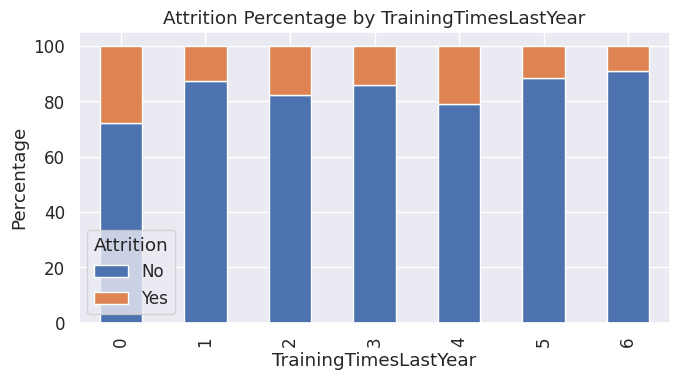


Attrition Percentage within WorkLifeBalance


Attrition,No,Yes
WorkLifeBalance,,
1,68.75,31.25
2,83.14,16.86
3,85.78,14.22
4,82.35,17.65


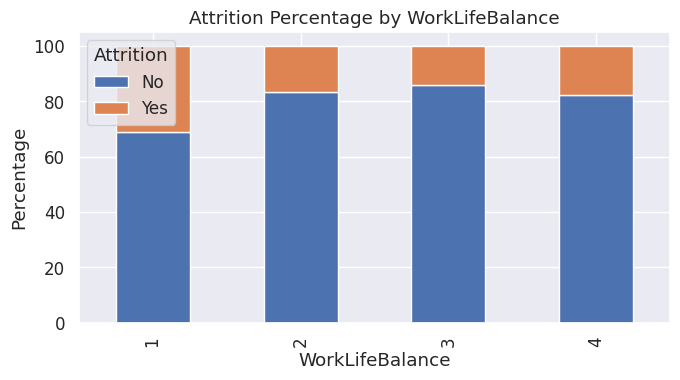

In [30]:
for col in ordinal_features:

    ct = pd.crosstab(
        df[col],
        df[target_feature],
        normalize="index"
    ) * 100

    print(f"\nAttrition Percentage within {col}")
    display(ct.round(2))

    ct = ct.sort_index()

    ct.plot(
        kind="bar",
        stacked=True,
        figsize=(7,4)
    )

    plt.title(f"Attrition Percentage by {col}")
    plt.ylabel("Percentage")
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

*Categorical Features vs Attrition*


Attrition Percentage within BusinessTravel


Attrition,No,Yes
BusinessTravel,,
Non-Travel,92.00,8.00
Travel_Frequently,75.09,24.91
Travel_Rarely,85.04,14.96


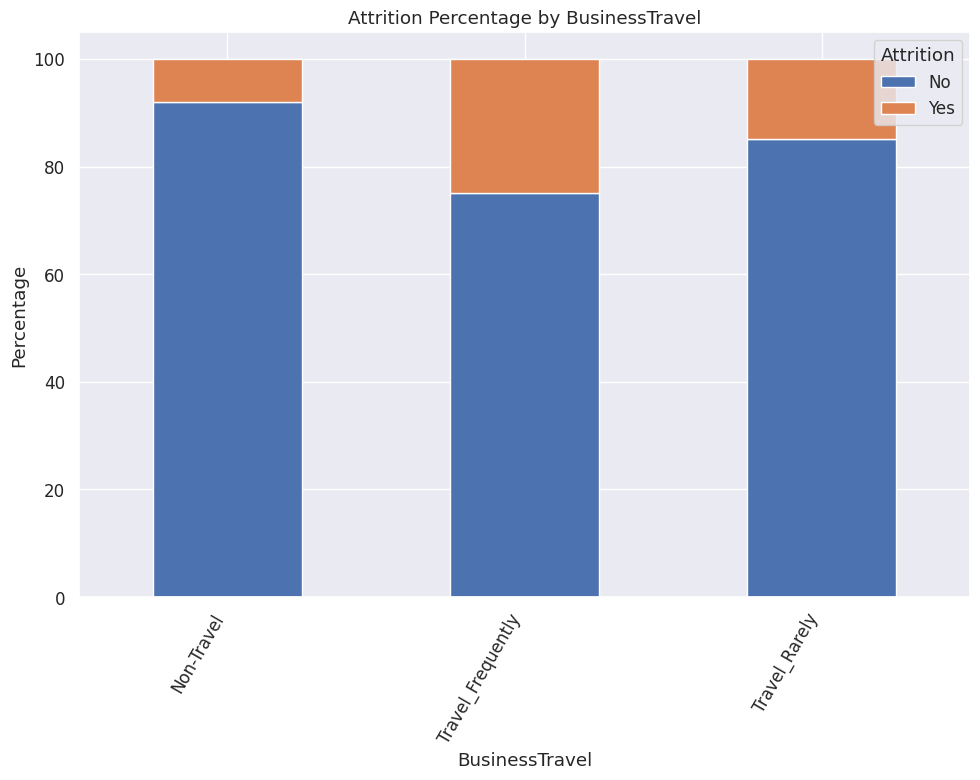


Attrition Percentage within Department


Attrition,No,Yes
Department,,
Human Resources,80.95,19.05
Research & Development,86.16,13.84
Sales,79.37,20.63


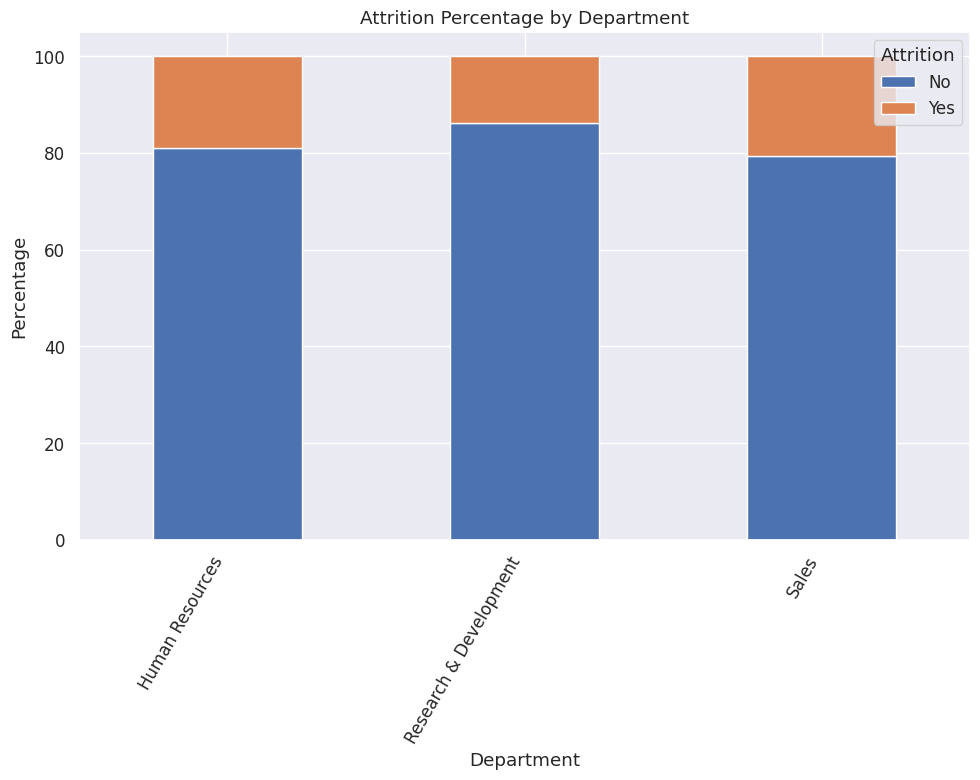


Attrition Percentage within EducationField


Attrition,No,Yes
EducationField,,
Human Resources,74.07,25.93
Life Sciences,85.31,14.69
Marketing,77.99,22.01
Medical,86.42,13.58
Other,86.59,13.41
Technical Degree,75.76,24.24


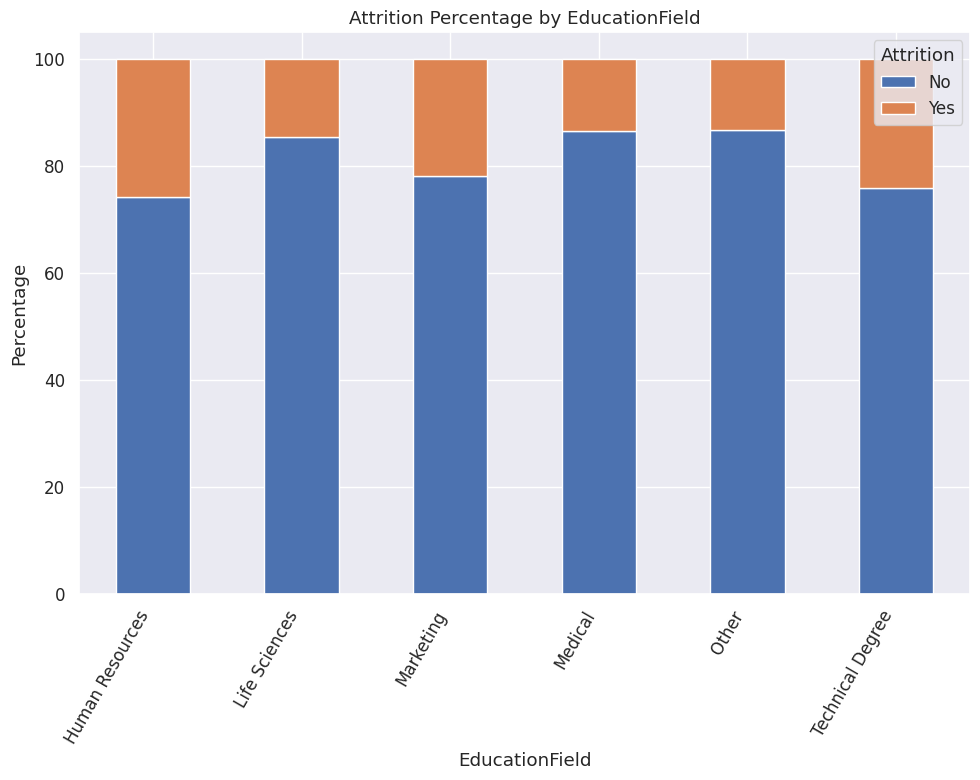


Attrition Percentage within Gender


Attrition,No,Yes
Gender,,
Female,85.20,14.80
Male,82.99,17.01


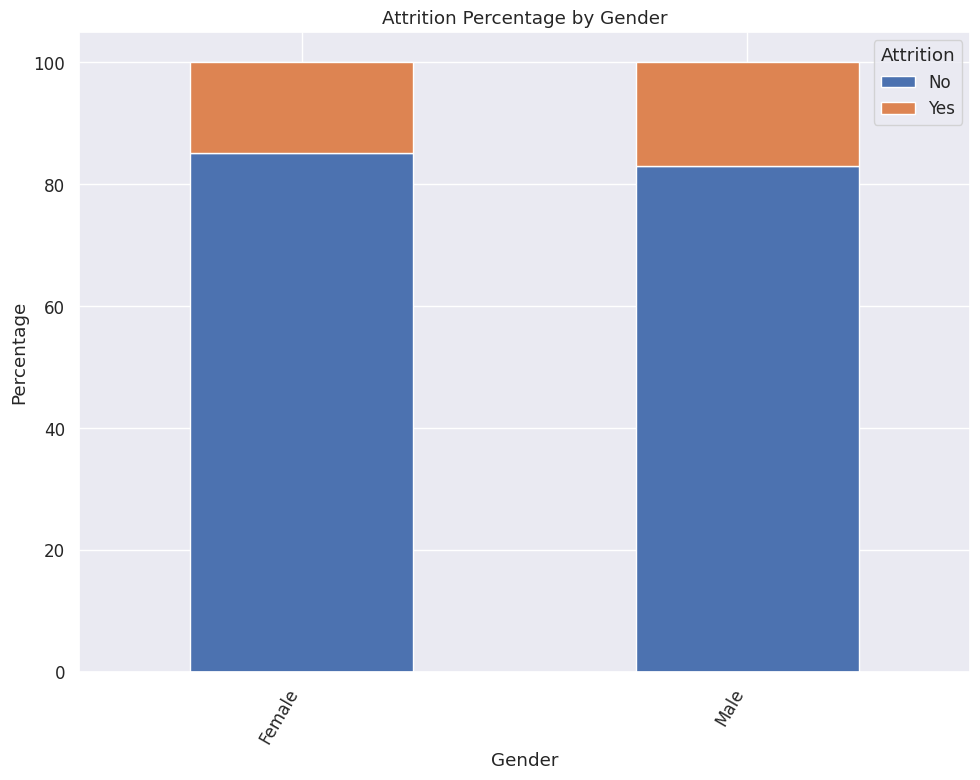


Attrition Percentage within JobRole


Attrition,No,Yes
JobRole,,
Healthcare Representative,93.13,6.87
Human Resources,76.92,23.08
Laboratory Technician,76.06,23.94
Manager,95.10,4.90
Manufacturing Director,93.10,6.90
Research Director,97.50,2.50
Research Scientist,83.90,16.10
Sales Executive,82.52,17.48
Sales Representative,60.24,39.76


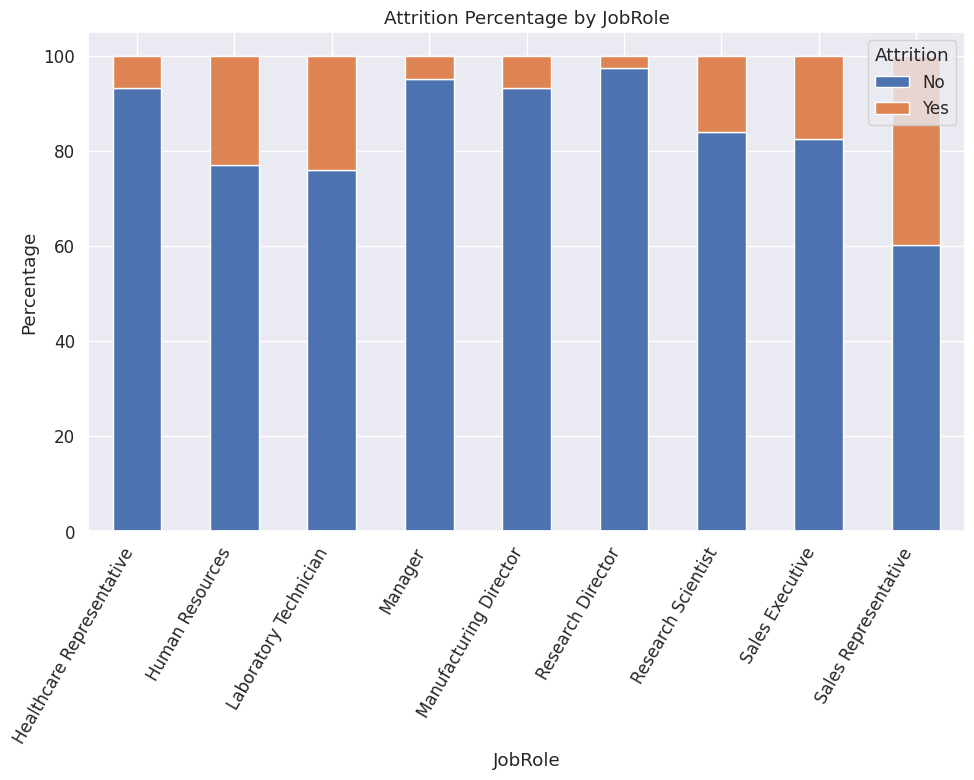


Attrition Percentage within MaritalStatus


Attrition,No,Yes
MaritalStatus,,
Divorced,89.91,10.09
Married,87.52,12.48
Single,74.47,25.53


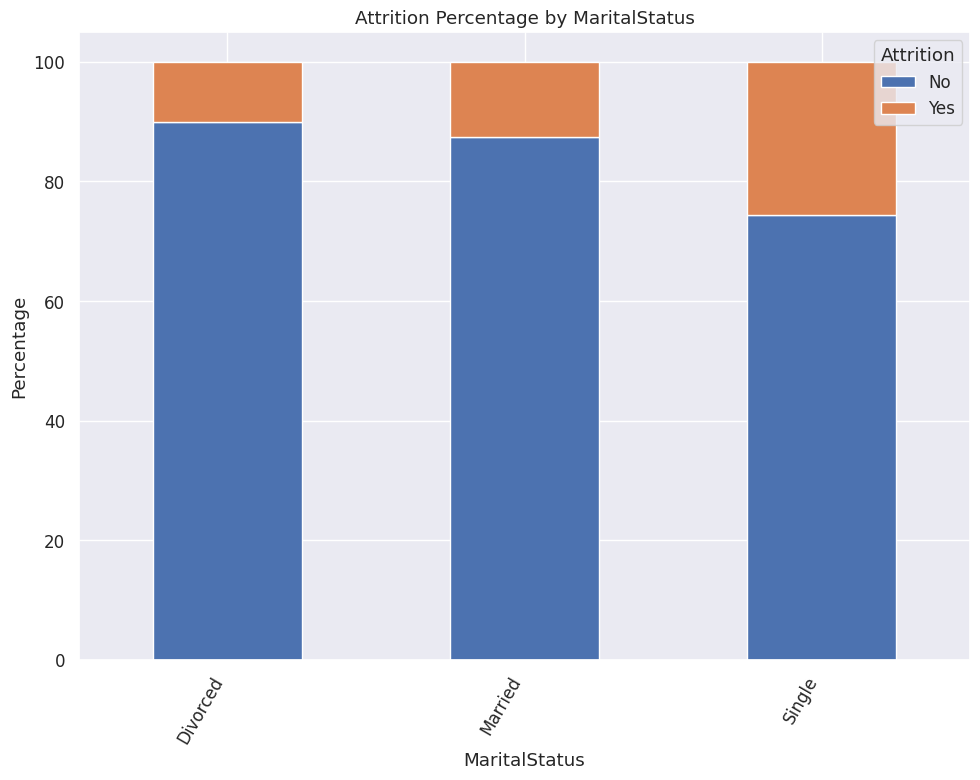


Attrition Percentage within OverTime


Attrition,No,Yes
OverTime,,
No,89.56,10.44
Yes,69.47,30.53


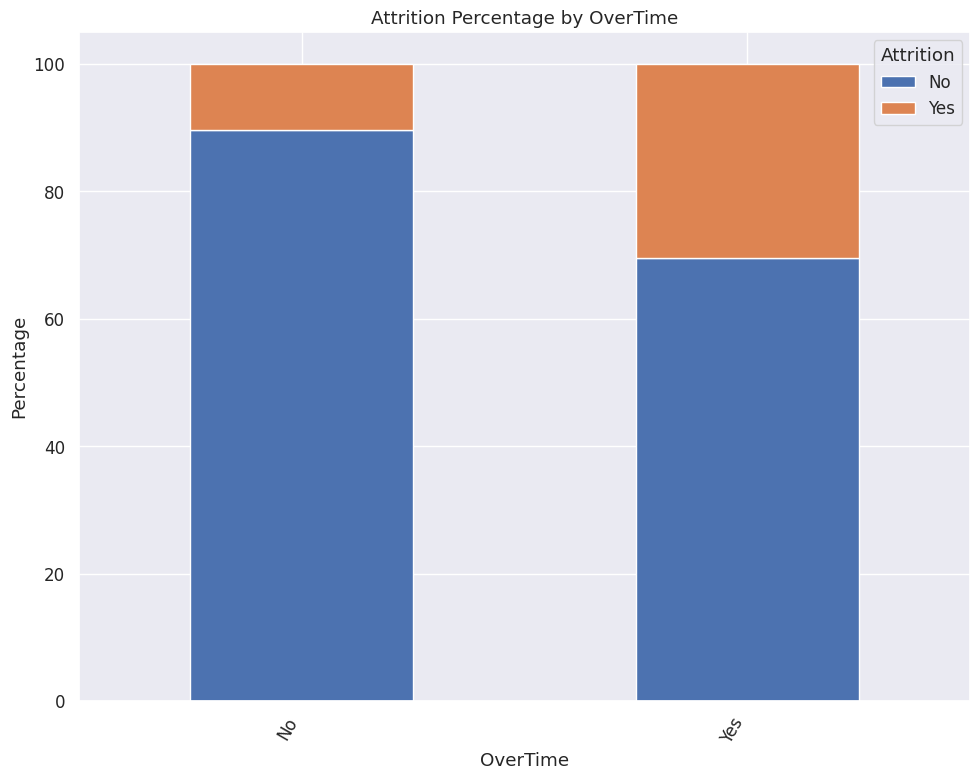

In [31]:
for c in categorical_features:
    ct = pd.crosstab(
        df[c],
        df[target_feature],
        normalize="index"
    ) * 100

    print(f"\nAttrition Percentage within {c}")
    display(ct.round(2))

    ct.plot(
        kind="bar",
        stacked=True,
        figsize=(10,8)
    )

    plt.title(f"Attrition Percentage by {c}")
    plt.ylabel("Percentage")
    plt.xticks(rotation=60, ha="right")

    plt.tight_layout()
    plt.show()

*Continuous Features vs Attrition*

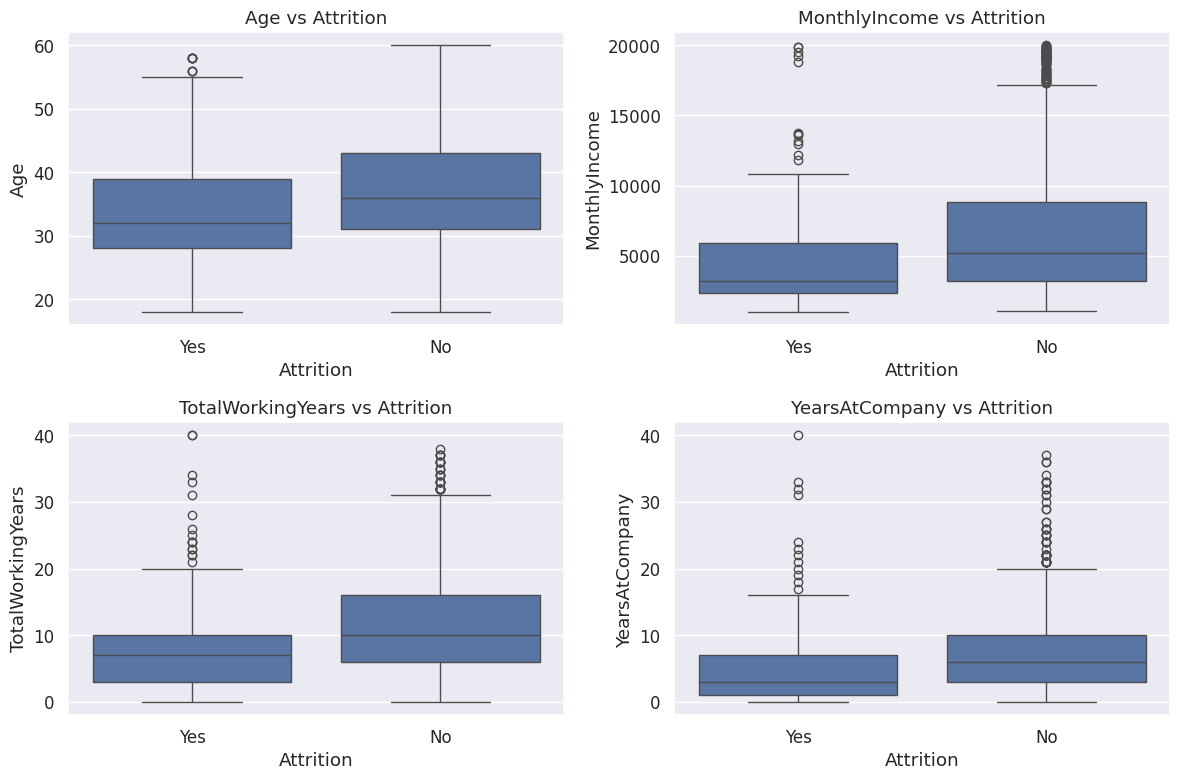

In [32]:
continuous_features = [
    'Age',
    'MonthlyIncome',
    'TotalWorkingYears',
    'YearsAtCompany'
]

plt.figure(figsize=(12,8))

for i, col in enumerate(continuous_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x=target_feature, y=col)
    plt.title(f"{col} vs Attrition")

plt.tight_layout()
plt.show()

Correlation Matrix and Heatmap

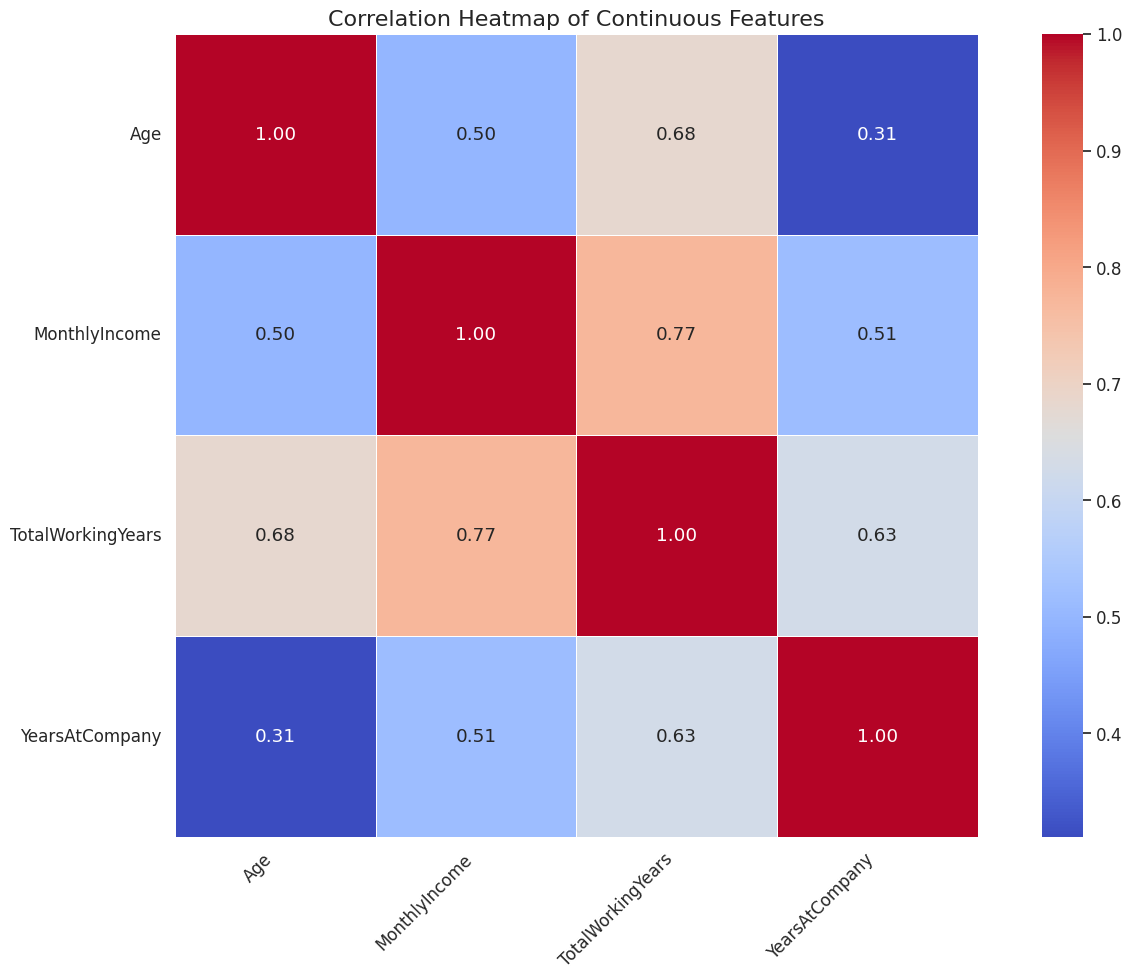

In [33]:
corr_matrix = df[continuous_features].corr()
plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title(
    "Correlation Heatmap of Continuous Features",
    fontsize=16
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [34]:
corr_matrix.T

,Age,MonthlyIncome,TotalWorkingYears,YearsAtCompany
Age,1.000000,0.497855,0.680381,0.311309
MonthlyIncome,0.497855,1.000000,0.772893,0.514285
TotalWorkingYears,0.680381,0.772893,1.000000,0.628133
YearsAtCompany,0.311309,0.514285,0.628133,1.000000


Analyze Target Variable (Attrition)

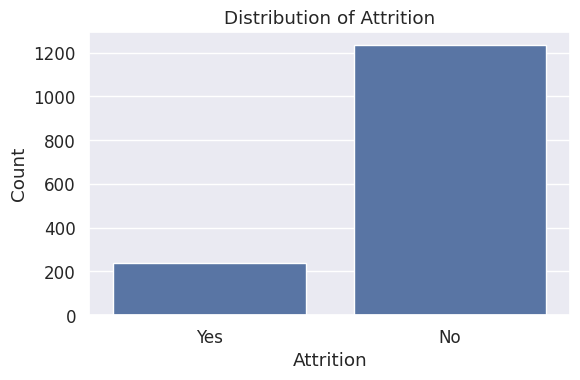

In [35]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x=target_feature
)

plt.title(f"Distribution of {target_feature}")
plt.xlabel(target_feature)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [36]:
print(df[target_feature].value_counts())

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [37]:
(df[target_feature].value_counts(normalize=True)*100).round(2)

,proportion
Attrition,
No,83.88
Yes,16.12


##Data Preprocessing

In [38]:
df.columns.tolist()

['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'Over18',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [39]:
for col in [
    "EmployeeCount",
    "EmployeeNumber",
    "Over18",
    "StandardHours"
]:
    print(f"\n{col}")
    print(df[col].value_counts())


EmployeeCount
EmployeeCount
1    1470
Name: count, dtype: int64

EmployeeNumber
EmployeeNumber
2068    1
1       1
2       1
4       1
5       1
       ..
23      1
22      1
21      1
20      1
19      1
Name: count, Length: 1470, dtype: int64

Over18
Over18
Y    1470
Name: count, dtype: int64

StandardHours
StandardHours
80    1470
Name: count, dtype: int64


In [40]:
df = df.drop(
    columns=[
        "EmployeeCount",
        "EmployeeNumber",
        "Over18",
        "StandardHours"
    ]
)

In [41]:
print(df.shape)
print(df.columns.tolist())

(1470, 31)
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


**Feature Encoding**

In [42]:
# OneHot Encoding for nominal categorical columns

df_encoded = pd.get_dummies(
    df,
    columns=categorical_features,
    drop_first=True,
    dtype =int
)

print(df_encoded.shape)

(1470, 45)


In [43]:
df_encoded.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,Yes,1102,1,2,2,94,3,2,4,...,0,0,0,0,0,1,0,0,1,1
1,49,No,279,8,1,3,61,2,2,2,...,0,0,0,0,1,0,0,1,0,0
2,37,Yes,1373,2,2,4,92,2,1,3,...,1,0,0,0,0,0,0,0,1,1
3,33,No,1392,3,4,4,56,3,1,3,...,0,0,0,0,1,0,0,1,0,1
4,27,No,591,2,1,1,40,3,1,2,...,1,0,0,0,0,0,0,1,0,0


In [44]:
#Label Encoding to target feature
df_encoded[target_feature] = df_encoded[target_feature].map(
    {
    "No" : 0,
    "Yes" : 1
    }
)

df_encoded[target_feature].value_counts()

,count
Attrition,
0,1233
1,237


In [45]:
df_encoded.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,0,0,0,0,0,1,0,0,1,1
1,49,0,279,8,1,3,61,2,2,2,...,0,0,0,0,1,0,0,1,0,0
2,37,1,1373,2,2,4,92,2,1,3,...,1,0,0,0,0,0,0,0,1,1
3,33,0,1392,3,4,4,56,3,1,3,...,0,0,0,0,1,0,0,1,0,1
4,27,0,591,2,1,1,40,3,1,2,...,1,0,0,0,0,0,0,1,0,0


Separate X and y

In [46]:
X = df_encoded.drop("Attrition",axis=1)
y = df_encoded["Attrition"]

Train-Test Split

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y

)

In [48]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1176, 44)
(294, 44)
(1176,)
(294,)


**Pipeline**

Model Creation

In [49]:
log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        random_state=42,
        max_iter=5000
    ))
])

rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

In [50]:
#Model To Train
models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf,
    "XGBoost": xgb
}

In [51]:
results = []

In [52]:
for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc
    })

    print(f"\n{name}")
    print(classification_report(y_test, y_pred))


Logistic Regression
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294


Random Forest
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.44      0.09      0.14        47

    accuracy                           0.84       294
   macro avg       0.65      0.53      0.53       294
weighted avg       0.78      0.84      0.79       294


XGBoost
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.58      0.23      0.33        47

    accuracy                           0.85       294
   macro avg       0.72      0.60      0.62       294
weighted avg       0.82      

Logistic Regression Cross Validation

In [53]:
cv_scores_log = cross_val_score(
    log_reg,
    X_train,
    y_train,
    cv=5,
    scoring="recall"
)

print("CV Recall Scores:", cv_scores_log)
print("Mean Recall:", np.mean(cv_scores_log))
print("Std Recall:", np.std(cv_scores_log))

CV Recall Scores: [0.36842105 0.5        0.44736842 0.39473684 0.47368421]
Mean Recall: 0.436842105263158
Std Recall: 0.048808518397345804


Hyperparameter Tuning

In [54]:
#Parameter Grid
param_grid_log = {
    "model__C": [0.01, 0.1, 1, 10, 100]
}

In [55]:
#GridSearchCV
grid_log = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid_log,
    scoring="recall",
    cv=5,
    n_jobs=-1,
    error_score="raise"
)

In [56]:
#Train Grid Search
grid_log.fit(X_train, y_train)

GridSearchCV(cv=5, error_score='raise',
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model',
                                        LogisticRegression(max_iter=5000,
                                                           random_state=42))]),
             n_jobs=-1, param_grid={'model__C': [0.01, 0.1, 1, 10, 100]},
             scoring='recall')

In [57]:
#Check Best performance
print("Best Parameters:", grid_log.best_params_)
print("Best CV Recall:", grid_log.best_score_)

Best Parameters: {'model__C': 10}
Best CV Recall: 0.4473684210526316


In [58]:
#Extract best Model
best_log_reg = grid_log.best_estimator_

In [59]:
#Evaluate on Test Set
y_pred_best = best_log_reg.predict(X_test)

y_prob_best = best_log_reg.predict_proba(X_test)[:,1]

In [60]:
#Metrics
print(classification_report(
    y_test,
    y_pred_best
))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.59      0.34      0.43        47

    accuracy                           0.86       294
   macro avg       0.74      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



In [61]:
print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_best))

ROC-AUC: 0.8067878370229994


Threshold Tuning

In [62]:
y_test_proba = best_log_reg.predict_proba(X_test)[:,1]

Run Threshold Tuning

In [63]:
thresholds = np.linspace(0.1, 0.9, 9)

rows = []

for thr in thresholds:

    y_thr_pred = (y_test_proba >= thr).astype(int)

    acc_thr = accuracy_score(y_test, y_thr_pred)

    prec_thr = precision_score(y_test, y_thr_pred)

    rec_thr = recall_score(y_test, y_thr_pred)

    f1_thr = f1_score(y_test, y_thr_pred)

    rows.append([
        thr,
        acc_thr,
        prec_thr,
        rec_thr,
        f1_thr
    ])

thr_df = pd.DataFrame(
    rows,
    columns=[
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

thr_df

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.1,0.721088,0.336449,0.765957,0.467532
1,0.2,0.806122,0.428571,0.638298,0.512821
2,0.3,0.840136,0.500000,0.510638,0.505263
3,0.4,0.853741,0.552632,0.446809,0.494118
4,0.5,0.857143,0.592593,0.340426,0.432432
5,0.6,0.870748,0.714286,0.319149,0.441176
6,0.7,0.874150,0.916667,0.234043,0.372881
7,0.8,0.867347,1.000000,0.170213,0.290909
8,0.9,0.846939,1.000000,0.042553,0.081633


Plot Precision vs Recall

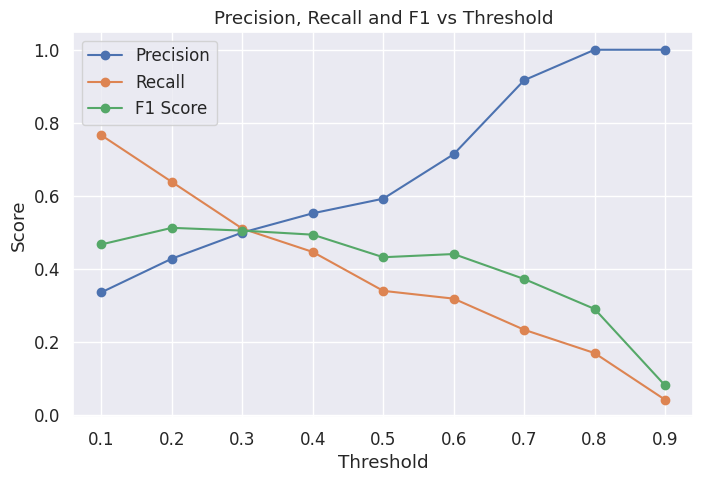

In [64]:
plt.figure(figsize=(8,5))

plt.plot(
    thr_df["Threshold"],
    thr_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    thr_df["Threshold"],
    thr_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    thr_df["Threshold"],
    thr_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 vs Threshold")

plt.grid(True)
plt.legend()

plt.show()

Applying the new Threshold in the model

In [65]:
y_prob_final = best_log_reg.predict_proba(X_test)[:,1]

y_pred_final = (y_prob_final >= 0.2).astype(int)

Evaluate

In [66]:
print(classification_report(
    y_test,
    y_pred_final
))

              precision    recall  f1-score   support

           0       0.92      0.84      0.88       247
           1       0.43      0.64      0.51        47

    accuracy                           0.81       294
   macro avg       0.68      0.74      0.70       294
weighted avg       0.84      0.81      0.82       294



Confusion Matrix

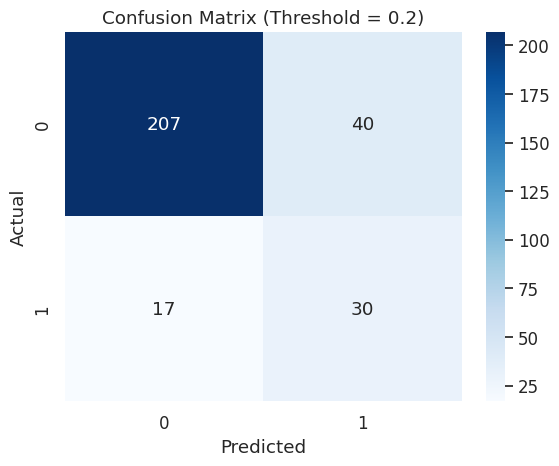

In [67]:
cm = confusion_matrix(
    y_test,
    y_pred_final
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix (Threshold = 0.2)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Random Forest Hyperparameter Tuning

Define Parameter Grid

In [68]:
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

GridSearchCV

In [69]:
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    scoring="recall",
    cv=5,
    n_jobs=-1,
    verbose=1
)

Train

In [70]:
grid_rf.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='recall', verbose=1)

Check Best Parameters

In [71]:
print("Best Parameters:", grid_rf.best_params_)
print("Best CV Recall:", grid_rf.best_score_)

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Best CV Recall: 0.46315789473684205


Evaluate Best Model

In [72]:
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)

y_prob_rf = best_rf.predict_proba(X_test)[:,1]

Metrics

In [73]:
print(classification_report(
    y_test,
    y_pred_rf
))

              precision    recall  f1-score   support

           0       0.89      0.89      0.89       247
           1       0.42      0.43      0.42        47

    accuracy                           0.81       294
   macro avg       0.65      0.66      0.65       294
weighted avg       0.81      0.81      0.81       294



ROC-AUC

In [74]:
print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob_rf)
)

ROC-AUC: 0.7645792057886123


Confusion Matrix

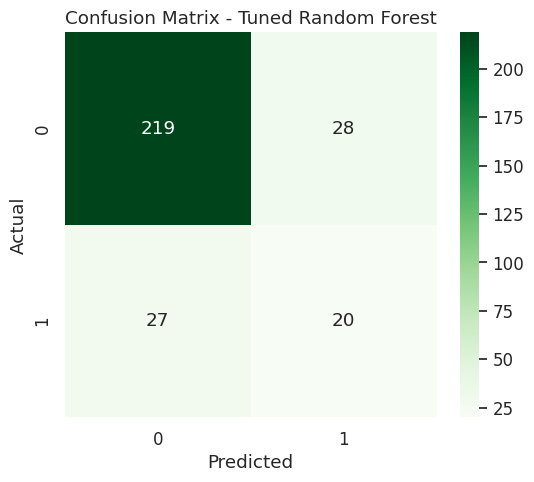

In [75]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Confusion Matrix - Tuned Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

XGBoost Hyperparameter Tuning

Define Parameter Grid

In [76]:
param_grid_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2]
}

Create GridSearchCV

In [77]:
grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    scoring="recall",
    cv=5,
    n_jobs=-1,
    verbose=1
)

Train

In [78]:
grid_xgb.fit(X_train, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7], 'n_estimators': [100, 200]},
             scoring='recall', verbose=1)

Best Parameters

In [79]:
print("Best Parameters:", grid_xgb.best_params_)
print("Best CV Recall:", grid_xgb.best_score_)

Best Parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200}
Best CV Recall: 0.39473684210526316


Evaluate Tuned Model

In [80]:
best_xgb = grid_xgb.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)

y_prob_xgb = best_xgb.predict_proba(X_test)[:,1]

Classification Report

In [81]:
print(classification_report(
    y_test,
    y_pred_xgb
))

              precision    recall  f1-score   support

           0       0.87      0.96      0.91       247
           1       0.55      0.23      0.33        47

    accuracy                           0.85       294
   macro avg       0.71      0.60      0.62       294
weighted avg       0.82      0.85      0.82       294



ROC-AUC

In [82]:
print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob_xgb)
)

ROC-AUC: 0.7694030493582564


Confusion Matrix

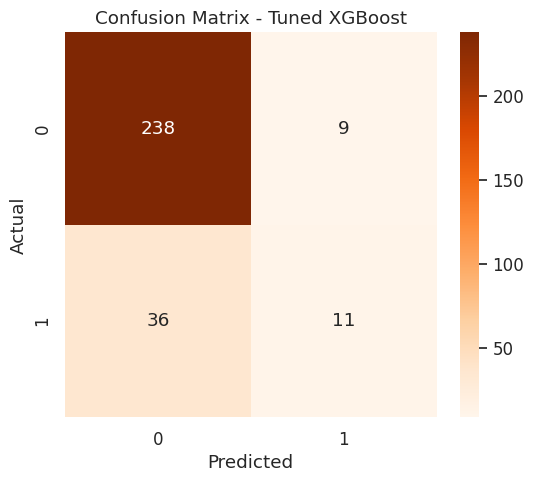

In [83]:
cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Confusion Matrix - Tuned XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**Extract Feature Importance from Logistic Regression**

In [84]:
best_log_reg

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(C=10, max_iter=5000, random_state=42))])

Sort Features

In [85]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": best_log_reg.named_steps["model"].coef_[0]
})

coef_df.head()

,Feature,Coefficient
0,Age,-0.408892
1,DailyRate,-0.189403
2,DistanceFromHome,0.404620
3,Education,0.014938
4,EnvironmentSatisfaction,-0.497648


Most Important Positive Features

In [86]:
coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

coef_df.head(10)

,Feature,Coefficient
43,OverTime_Yes,0.884783
23,BusinessTravel_Travel_Frequently,0.802618
34,JobRole_Laboratory Technician,0.794657
25,Department_Research & Development,0.776275
26,Department_Sales,0.726842
40,JobRole_Sales Representative,0.577884
39,JobRole_Sales Executive,0.563634
33,JobRole_Human Resources,0.551947
21,YearsSinceLastPromotion,0.548141
24,BusinessTravel_Travel_Rarely,0.504835


In [87]:
top_positive = coef_df.head(10)

print(top_positive)

                              Feature  Coefficient
43                       OverTime_Yes     0.884783
23   BusinessTravel_Travel_Frequently     0.802618
34      JobRole_Laboratory Technician     0.794657
25  Department_Research & Development     0.776275
26                   Department_Sales     0.726842
40       JobRole_Sales Representative     0.577884
39            JobRole_Sales Executive     0.563634
33            JobRole_Human Resources     0.551947
21            YearsSinceLastPromotion     0.548141
24       BusinessTravel_Travel_Rarely     0.504835


Most Important Negative Features

In [88]:
top_negative = coef_df.tail(10)

print(top_negative)

                         Feature  Coefficient
6                 JobInvolvement    -0.369746
37     JobRole_Research Director    -0.372867
0                            Age    -0.408892
22          YearsWithCurrManager    -0.416245
8                JobSatisfaction    -0.427530
30          EducationField_Other    -0.445842
4        EnvironmentSatisfaction    -0.497648
27  EducationField_Life Sciences    -0.575030
16             TotalWorkingYears    -0.597393
29        EducationField_Medical    -0.618160


Positive drivers:

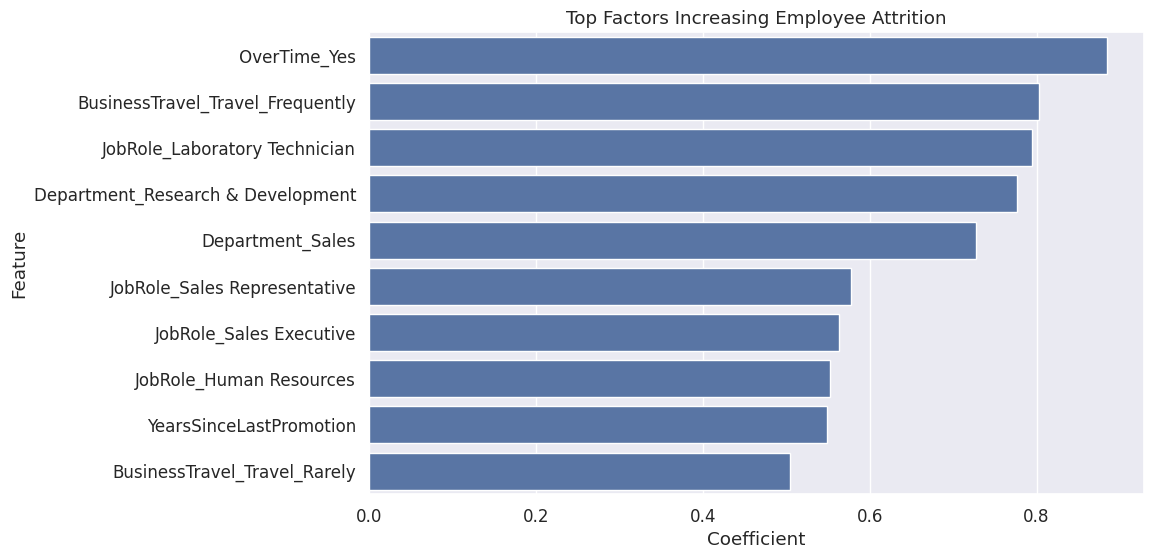

In [89]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_positive,
    x="Coefficient",
    y="Feature"
)

plt.title("Top Factors Increasing Employee Attrition")
plt.show()

Negative drivers:

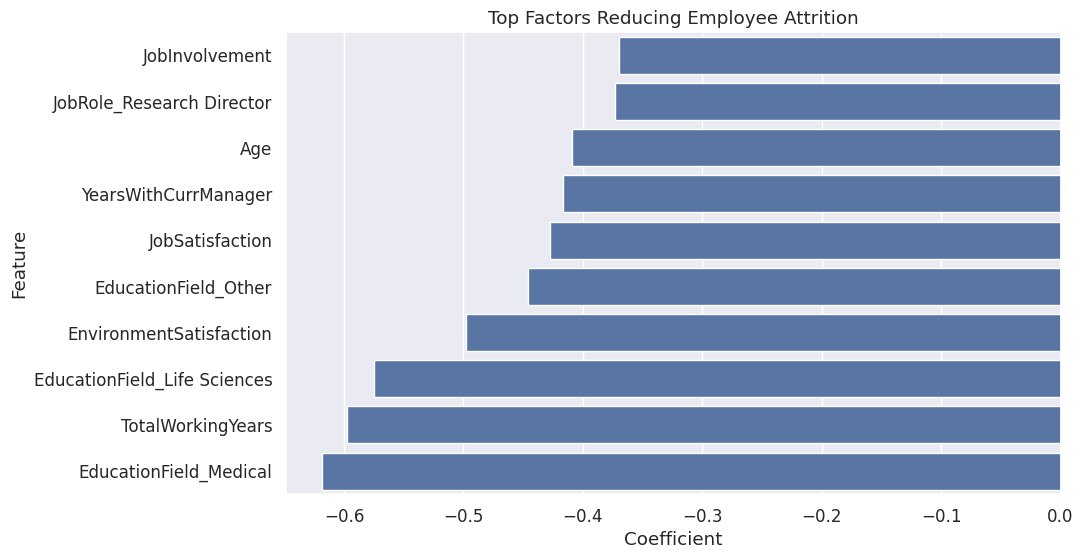

In [90]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_negative,
    x="Coefficient",
    y="Feature"
)

plt.title("Top Factors Reducing Employee Attrition")
plt.show()

Final Model Comparison Table

In [91]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression (0.5)",
        "Logistic Regression (0.2)",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        0.86,
        0.81,
        0.83,
        0.85
    ],
    "Precision": [
        0.59,
        0.43,
        0.42,
        0.55
    ],
    "Recall": [
        0.34,
        0.64,
        0.11,
        0.23
    ],
    "F1 Score": [
        0.43,
        0.51,
        0.17,
        0.33
    ],
    "ROC-AUC": [
        0.81,
        0.81,
        0.79,
        0.77
    ]
})

final_results.sort_values(
    by="Recall",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Logistic Regression (0.2),0.81,0.43,0.64,0.51,0.81
0,Logistic Regression (0.5),0.86,0.59,0.34,0.43,0.81
3,XGBoost,0.85,0.55,0.23,0.33,0.77
2,Random Forest,0.83,0.42,0.11,0.17,0.79


MLflow

In [92]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.3/86.3 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 907.5/907.5 kB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20

In [94]:
import mlflow
import mlflow.sklearn

Creating an Experiment

In [95]:
mlflow.set_experiment(
    "Employee_Attrition_Prediction"
)

2026/06/04 11:20:02 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/04 11:20:02 INFO mlflow.store.db.utils: Updating database tables
2026/06/04 11:20:05 INFO mlflow.tracking.fluent: Experiment with name 'Employee_Attrition_Prediction' does not exist. Creating a new experiment.


<Experiment: artifact_location='/content/mlruns/1', creation_time=1780572005814, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1780572005814, lifecycle_stage='active', name='Employee_Attrition_Prediction', tags={}, trace_location=None, workspace='default'>

Log the Final Result

In [96]:
for _, row in final_results.iterrows():

    with mlflow.start_run(
        run_name=row["Model"]
    ):

        mlflow.log_param(
            "Model",
            row["Model"]
        )

        mlflow.log_metric(
            "Accuracy",
            row["Accuracy"]
        )

        mlflow.log_metric(
            "Precision",
            row["Precision"]
        )

        mlflow.log_metric(
            "Recall",
            row["Recall"]
        )

        mlflow.log_metric(
            "F1_Score",
            row["F1 Score"]
        )

        mlflow.log_metric(
            "ROC_AUC",
            row["ROC-AUC"]
        )

Logged  Run

In [97]:
runs = mlflow.search_runs()

runs[
    [
        "tags.mlflow.runName",
        "metrics.Accuracy",
        "metrics.Precision",
        "metrics.Recall",
        "metrics.F1_Score",
        "metrics.ROC_AUC"
    ]
]

,tags.mlflow.runName,metrics.Accuracy,metrics.Precision,metrics.Recall,metrics.F1_Score,metrics.ROC_AUC
0,XGBoost,0.85,0.55,0.23,0.33,0.77
1,Random Forest,0.83,0.42,0.11,0.17,0.79
2,Logistic Regression (0.2),0.81,0.43,0.64,0.51,0.81
3,Logistic Regression (0.5),0.86,0.59,0.34,0.43,0.81


Log the final Model

In [98]:
with mlflow.start_run(
    run_name="Final_Logistic_Regression_Threshold_0.2"
):

    mlflow.log_param(
        "Model",
        "Logistic Regression"
    )

    mlflow.log_param(
        "Threshold",
        0.2
    )

    mlflow.log_metric(
        "Accuracy",
        0.81
    )

    mlflow.log_metric(
        "Precision",
        0.43
    )

    mlflow.log_metric(
        "Recall",
        0.64
    )

    mlflow.log_metric(
        "F1_Score",
        0.51
    )

    mlflow.log_metric(
        "ROC_AUC",
        0.81
    )

    mlflow.sklearn.log_model(
        best_log_reg,
        artifact_path="model"
    )

2026/06/04 11:20:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/04 11:20:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [99]:
mlflow.search_runs()

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.F1_Score,metrics.Recall,metrics.Accuracy,metrics.Precision,metrics.ROC_AUC,params.Threshold,params.Model,tags.mlflow.source.name,tags.mlflow.source.type,tags.mlflow.runName,tags.mlflow.user
0,d24b52836e0a4d27a496823d29125423,1,FINISHED,/content/mlruns/1/d24b52836e0a4d27a496823d2912...,2026-06-04 11:20:13.505000+00:00,2026-06-04 11:20:20.970000+00:00,0.51,0.64,0.81,0.43,0.81,0.2,Logistic Regression,fileId=1MI4Xz_nG-GwkX32-nGPdJ7CedVqhbTlR,NOTEBOOK,Final_Logistic_Regression_Threshold_0.2,root
1,7fd0ed19543e47ba917d7b19370b65d2,1,FINISHED,/content/mlruns/1/7fd0ed19543e47ba917d7b19370b...,2026-06-04 11:20:09.073000+00:00,2026-06-04 11:20:09.162000+00:00,0.33,0.23,0.85,0.55,0.77,None,XGBoost,fileId=1MI4Xz_nG-GwkX32-nGPdJ7CedVqhbTlR,NOTEBOOK,XGBoost,root
2,2161978e95164fbda8f7991be0508717,1,FINISHED,/content/mlruns/1/2161978e95164fbda8f7991be050...,2026-06-04 11:20:08.970000+00:00,2026-06-04 11:20:09.059000+00:00,0.17,0.11,0.83,0.42,0.79,None,Random Forest,fileId=1MI4Xz_nG-GwkX32-nGPdJ7CedVqhbTlR,NOTEBOOK,Random Forest,root
3,f3ea2d89398e4d018ec97ae057c1b75c,1,FINISHED,/content/mlruns/1/f3ea2d89398e4d018ec97ae057c1...,2026-06-04 11:20:08.860000+00:00,2026-06-04 11:20:08.954000+00:00,0.51,0.64,0.81,0.43,0.81,None,Logistic Regression (0.2),fileId=1MI4Xz_nG-GwkX32-nGPdJ7CedVqhbTlR,NOTEBOOK,Logistic Regression (0.2),root
4,6ea25b862585471687434eaab9076395,1,FINISHED,/content/mlruns/1/6ea25b862585471687434eaab907...,2026-06-04 11:20:08.734000+00:00,2026-06-04 11:20:08.841000+00:00,0.43,0.34,0.86,0.59,0.81,None,Logistic Regression (0.5),fileId=1MI4Xz_nG-GwkX32-nGPdJ7CedVqhbTlR,NOTEBOOK,Logistic Regression (0.5),root


Saving the Model


In [100]:
import joblib

joblib.dump(
    best_log_reg,
    "attrition_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


Verifying the File Exists

In [101]:
import os

os.listdir()

['.config',
 'mlruns',
 'mlflow.db',
 'attrition_model.pkl',
 'WA_Fn-UseC_-HR-Employee-Attrition 2.csv',
 'sample_data']

In [102]:
loaded_model = joblib.load(
    "attrition_model.pkl"
)

print(type(loaded_model))

<class 'sklearn.pipeline.Pipeline'>


In [103]:
print(X_train.shape)

(1176, 44)


In [104]:
print(X_train.columns.tolist())

['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Research & Development', 'Department_Sales', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'Gender_Male', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'JobRole_Sales Representative', 'MaritalStatus_Married', 'MaritalStatus_

In [105]:
print(X_train.columns.tolist())

['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Research & Development', 'Department_Sales', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'Gender_Male', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'JobRole_Sales Representative', 'MaritalStatus_Married', 'MaritalStatus_

Installing Gradio

In [106]:
!pip install gradio

Creating the Prediction Function

In [107]:
loaded_model.feature_names_in_

array(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate',
       'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'BusinessTravel_Travel_Frequently',
       'BusinessTravel_Travel_Rarely',
       'Department_Research & Development', 'Department_Sales',
       'EducationField_Life Sciences', 'EducationField_Marketing',
       'EducationField_Medical', 'EducationField_Other',
       'EducationField_Technical Degree', 'Gender_Male',
       'JobRole_Human Resources', 'JobRole_Laboratory Technician',
       'JobRole_Manager', 'JobRole_Manufacturing Director',
       'JobRole_Research Director', 'JobRole_Research 

In [108]:
list(loaded_model.feature_names_in_)

['Age',
 'DailyRate',
 'DistanceFromHome',
 'Education',
 'EnvironmentSatisfaction',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager',
 'BusinessTravel_Travel_Frequently',
 'BusinessTravel_Travel_Rarely',
 'Department_Research & Development',
 'Department_Sales',
 'EducationField_Life Sciences',
 'EducationField_Marketing',
 'EducationField_Medical',
 'EducationField_Other',
 'EducationField_Technical Degree',
 'Gender_Male',
 'JobRole_Human Resources',
 'JobRole_Laboratory Technician',
 'JobRole_Manager',
 'JobRole_Manufacturing Director',
 'JobRole_Research Director',
 'JobRole_Research Scientist',
 'JobRole_Sales Executive',
 'JobRole_Sales Representative',


In [ ]:
print(df["BusinessTravel"].unique())

print(df["Department"].unique())

print(df["EducationField"].unique())

print(df["Gender"].unique())

print(df["JobRole"].unique())

print(df["MaritalStatus"].unique())

print(df["OverTime"].unique())

In [109]:
df.median(numeric_only=True)

,0
Age,36.0
DailyRate,802.0
DistanceFromHome,7.0
Education,3.0
EnvironmentSatisfaction,3.0
HourlyRate,66.0
JobInvolvement,3.0
JobLevel,2.0
JobSatisfaction,3.0
MonthlyIncome,4919.0


In [110]:
import gradio as gr
import pandas as pd
import joblib

In [111]:
model = joblib.load("attrition_model.pkl")

print(type(model))

<class 'sklearn.pipeline.Pipeline'>


In [112]:
print(model.feature_names_in_)

['Age' 'DailyRate' 'DistanceFromHome' 'Education'
 'EnvironmentSatisfaction' 'HourlyRate' 'JobInvolvement' 'JobLevel'
 'JobSatisfaction' 'MonthlyIncome' 'MonthlyRate' 'NumCompaniesWorked'
 'PercentSalaryHike' 'PerformanceRating' 'RelationshipSatisfaction'
 'StockOptionLevel' 'TotalWorkingYears' 'TrainingTimesLastYear'
 'WorkLifeBalance' 'YearsAtCompany' 'YearsInCurrentRole'
 'YearsSinceLastPromotion' 'YearsWithCurrManager'
 'BusinessTravel_Travel_Frequently' 'BusinessTravel_Travel_Rarely'
 'Department_Research & Development' 'Department_Sales'
 'EducationField_Life Sciences' 'EducationField_Marketing'
 'EducationField_Medical' 'EducationField_Other'
 'EducationField_Technical Degree' 'Gender_Male' 'JobRole_Human Resources'
 'JobRole_Laboratory Technician' 'JobRole_Manager'
 'JobRole_Manufacturing Director' 'JobRole_Research Director'
 'JobRole_Research Scientist' 'JobRole_Sales Executive'
 'JobRole_Sales Representative' 'MaritalStatus_Married'
 'MaritalStatus_Single' 'OverTime_Yes']


In [113]:
def test_prediction():

    data = {
        'Age': 36,
        'DailyRate': 802,
        'DistanceFromHome': 7,
        'Education': 3,
        'EnvironmentSatisfaction': 3,
        'HourlyRate': 66,
        'JobInvolvement': 3,
        'JobLevel': 2,
        'JobSatisfaction': 3,
        'MonthlyIncome': 4919,
        'MonthlyRate': 14235.5,
        'NumCompaniesWorked': 2,
        'PercentSalaryHike': 14,
        'PerformanceRating': 3,
        'RelationshipSatisfaction': 3,
        'StockOptionLevel': 1,
        'TotalWorkingYears': 10,
        'TrainingTimesLastYear': 3,
        'WorkLifeBalance': 3,
        'YearsAtCompany': 5,
        'YearsInCurrentRole': 3,
        'YearsSinceLastPromotion': 1,
        'YearsWithCurrManager': 3,

        'BusinessTravel_Travel_Frequently': 0,
        'BusinessTravel_Travel_Rarely': 1,

        'Department_Research & Development': 1,
        'Department_Sales': 0,

        'EducationField_Life Sciences': 1,
        'EducationField_Marketing': 0,
        'EducationField_Medical': 0,
        'EducationField_Other': 0,
        'EducationField_Technical Degree': 0,

        'Gender_Male': 1,

        'JobRole_Human Resources': 0,
        'JobRole_Laboratory Technician': 0,
        'JobRole_Manager': 0,
        'JobRole_Manufacturing Director': 0,
        'JobRole_Research Director': 0,
        'JobRole_Research Scientist': 1,
        'JobRole_Sales Executive': 0,
        'JobRole_Sales Representative': 0,

        'MaritalStatus_Married': 0,
        'MaritalStatus_Single': 1,

        'OverTime_Yes': 1
    }

    df_input = pd.DataFrame([data])

    df_input = df_input[
        model.feature_names_in_
    ]

    probability = model.predict_proba(df_input)[0][1]

    return probability

In [114]:
test_prediction()

np.float64(0.14107519422881304)

In [115]:
def predict_attrition(
    age,
    monthly_income,
    total_working_years,
    years_at_company,
    years_since_last_promotion,
    years_with_curr_manager,
    env_satisfaction,
    job_satisfaction,
    job_involvement,
    business_travel,
    department,
    education_field,
    gender,
    job_role,
    marital_status,
    overtime
):

    data = {
        'Age': 36,
        'DailyRate': 802,
        'DistanceFromHome': 7,
        'Education': 3,
        'EnvironmentSatisfaction': 3,
        'HourlyRate': 66,
        'JobInvolvement': 3,
        'JobLevel': 2,
        'JobSatisfaction': 3,
        'MonthlyIncome': 4919,
        'MonthlyRate': 14235.5,
        'NumCompaniesWorked': 2,
        'PercentSalaryHike': 14,
        'PerformanceRating': 3,
        'RelationshipSatisfaction': 3,
        'StockOptionLevel': 1,
        'TotalWorkingYears': 10,
        'TrainingTimesLastYear': 3,
        'WorkLifeBalance': 3,
        'YearsAtCompany': 5,
        'YearsInCurrentRole': 3,
        'YearsSinceLastPromotion': 1,
        'YearsWithCurrManager': 3,

        'BusinessTravel_Travel_Frequently': 0,
        'BusinessTravel_Travel_Rarely': 0,

        'Department_Research & Development': 0,
        'Department_Sales': 0,

        'EducationField_Life Sciences': 0,
        'EducationField_Marketing': 0,
        'EducationField_Medical': 0,
        'EducationField_Other': 0,
        'EducationField_Technical Degree': 0,

        'Gender_Male': 0,

        'JobRole_Human Resources': 0,
        'JobRole_Laboratory Technician': 0,
        'JobRole_Manager': 0,
        'JobRole_Manufacturing Director': 0,
        'JobRole_Research Director': 0,
        'JobRole_Research Scientist': 0,
        'JobRole_Sales Executive': 0,
        'JobRole_Sales Representative': 0,

        'MaritalStatus_Married': 0,
        'MaritalStatus_Single': 0,

        'OverTime_Yes': 0
    }

    # User values
    data['Age'] = age
    data['MonthlyIncome'] = monthly_income
    data['TotalWorkingYears'] = total_working_years
    data['YearsAtCompany'] = years_at_company
    data['YearsSinceLastPromotion'] = years_since_last_promotion
    data['YearsWithCurrManager'] = years_with_curr_manager

    data['EnvironmentSatisfaction'] = env_satisfaction
    data['JobSatisfaction'] = job_satisfaction
    data['JobInvolvement'] = job_involvement

    # One-hot encoding

    if business_travel == "Travel_Frequently":
        data['BusinessTravel_Travel_Frequently'] = 1
    elif business_travel == "Travel_Rarely":
        data['BusinessTravel_Travel_Rarely'] = 1

    if department == "Research & Development":
        data['Department_Research & Development'] = 1
    elif department == "Sales":
        data['Department_Sales'] = 1

    if education_field != "Human Resources":
        data[f'EducationField_{education_field}'] = 1

    if gender == "Male":
        data['Gender_Male'] = 1

    if job_role != "Healthcare Representative":
        data[f'JobRole_{job_role}'] = 1

    if marital_status == "Married":
        data['MaritalStatus_Married'] = 1
    elif marital_status == "Single":
        data['MaritalStatus_Single'] = 1

    if overtime == "Yes":
        data['OverTime_Yes'] = 1

    df_input = pd.DataFrame([data])

    df_input = df_input[
        model.feature_names_in_
    ]

    probability = model.predict_proba(df_input)[0][1]

    prediction = (
        "Likely to Leave"
        if probability >= 0.2
        else "Likely to Stay"
    )

    return (
        f"{prediction}\n"
        f"Attrition Probability: {probability:.2%}"
    )

In [116]:
predict_attrition(
    25,
    2500,
    2,
    1,
    1,
    1,
    1,
    1,
    2,
    "Travel_Frequently",
    "Sales",
    "Marketing",
    "Male",
    "Sales Representative",
    "Single",
    "Yes"
)

'Likely to Leave\nAttrition Probability: 98.95%'

#Building the Gradio Interface

In [117]:
demo = gr.Interface(
    fn=predict_attrition,

    inputs=[

        gr.Number(label="Age"),

        gr.Number(label="Monthly Income"),

        gr.Number(label="Total Working Years"),

        gr.Number(label="Years At Company"),

        gr.Number(label="Years Since Last Promotion"),

        gr.Number(label="Years With Current Manager"),

        gr.Dropdown(
            [1, 2, 3, 4],
            label="Environment Satisfaction"
        ),

        gr.Dropdown(
            [1, 2, 3, 4],
            label="Job Satisfaction"
        ),

        gr.Dropdown(
            [1, 2, 3, 4],
            label="Job Involvement"
        ),

        gr.Dropdown(
            [
                "Travel_Rarely",
                "Travel_Frequently",
                "Non-Travel"
            ],
            label="Business Travel"
        ),

        gr.Dropdown(
            [
                "Sales",
                "Research & Development",
                "Human Resources"
            ],
            label="Department"
        ),

        gr.Dropdown(
            [
                "Life Sciences",
                "Medical",
                "Marketing",
                "Technical Degree",
                "Other",
                "Human Resources"
            ],
            label="Education Field"
        ),

        gr.Dropdown(
            [
                "Male",
                "Female"
            ],
            label="Gender"
        ),

        gr.Dropdown(
            [
                "Sales Executive",
                "Research Scientist",
                "Laboratory Technician",
                "Manufacturing Director",
                "Healthcare Representative",
                "Manager",
                "Sales Representative",
                "Research Director",
                "Human Resources"
            ],
            label="Job Role"
        ),

        gr.Dropdown(
            [
                "Single",
                "Married",
                "Divorced"
            ],
            label="Marital Status"
        ),

        gr.Dropdown(
            [
                "Yes",
                "No"
            ],
            label="OverTime"
        )
    ],

    outputs=gr.HTML(
        label="Prediction Result"
    ),

    title="Employee Attrition Prediction System",

    description="""
    Enter employee information to predict the likelihood of attrition.
    The model uses a tuned Logistic Regression model and provides
    risk assessment along with retention recommendations.
    """
)

In [118]:
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1dd6967a85fe123d58.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Downloading the model

In [119]:
from google.colab import files

files.download("attrition_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>